<a href="https://colab.research.google.com/github/dukanx/Napredna_analiza_podataka_Projekat-Job_Postings_Analysis/blob/main/ProjekatNAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Dinamike IT Tržišta Rada: LLM Ekstrakcija i Mrežna Analiza Tehnologija

**Kurs:** Napredna Analiza Podataka  
**Autor:** Nikola Dukić

**Dataset:** LinkedIn Job Postings 2023/2024 (Kaggle)  
**Broj oglasa:** 1,460 IT pozicija

---

## Cilj Projekta

Analiza IT tržišta rada kroz dva pristupa:

1. **LLM Ekstrakcija** - Automatsko izvlačenje implicitnih karakteristika oglasa (tehnologije, ton, benefiti)
2. **Mrežna Analiza** - Mapiranje ekosistema tehnologija kroz co-occurrence grafove
3. **Korelaciona Analiza** - Ispitivanje uticaja širine znanja na platu i tona oglasa na angažovanje kandidata

---

## Istraživačka Pitanja

1. **Tehnološki Ekosistem:** Kako su tehnologije povezane? Koji su glavni klasteri?
2. **Plata vs Veštine:** Da li šira raznolikost tehnologija donosi veću platu?
3. **Ton Oglasa:** Da li red/green flags utiču na broj aplikacija?

---

Importi i instaliranje potrebnih biblioteka

In [ ]:
!pip install -q langchain langchain_groq pyvis networkx matplotlib tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.7 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
from os import environ
import pandas as pd
from google.colab import drive
from typing import List, Optional
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
import time
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import warnings
from pyvis.network import Network
from collections import Counter
import networkx as nx
import re
import pickle
from scipy import stats
from tabulate import tabulate

uvozimo API key i povezujemo google drive folder za uzimanje i slanje fajlova

In [ ]:
environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [ ]:
#drive.mount('/content/drive')

---

## **KORAK 1: FILTRIRANJE IT OGLASA IZ LINKEDIN DATASETA**

### **Kontekst:**
LinkedIn dataset sadrži **33,000+ oglasa** iz svih industrija. Naš fokus je isključivo **IT sektor**, ali LinkedIn kategorizacija industrija nije dovoljno precizna - mnogo oglasa je pogrešno kategorisano ili pripada graničnim oblastima (npr. "Technology" može biti i IT support i hardware engineering).

### **Strategija: Dvostepeno Filtriranje**

**Korak 1a: Broad Industry Filter**
```python
search_terms = ['Software', 'Data', 'Internet', 'Technology', ...]
```
Povezujemo `postings.csv` sa `industries.csv` preko `job_industries.csv` mapping tabele. Ovo daje **prvi sloj** filtriranja - zadržavamo sve oglase čije kompanije imaju IT-related industry tag.




**Korak 1b: Keyword-Based Title Filter**
```python
include_keywords = ['developer', 'engineer', 'data scientist', ...]
exclude_keywords = ['sales', 'marketing', 'hr', ...]
```

Filtriramo naslove pozicija. Ako naslov sadrži "Software Engineer" ALI takođe sadrži "Sales" (npr. "Software Sales Engineer"), eliminiše se.


---

maskiranje iz industries.csv fajla


In [ ]:
base_path = "/content/drive/MyDrive/ProjekatNAP/"

try:

    df_industries = pd.read_csv(base_path + "industries.csv")


    search_terms = [
        'Software', 'Data', 'Internet', 'Technology',
        'Information', 'Computer', 'Network', 'Telecommunication'
    ]
    mask = df_industries['industry_name'].str.contains('|'.join(search_terms), case=False, na=False)

    it_industries = df_industries[mask]

    target_industry_ids = it_industries['industry_id'].unique().tolist()
    display(it_industries.head(10))

except FileNotFoundError:
    print("Fajl ne postoji.")

,industry_id,industry_name
1,3,Computer Hardware Manufacturing
2,4,Software Development
3,5,Computer Networking Products
4,6,"Technology, Information and Internet"
6,8,Telecommunications
10,12,Biotechnology Research
22,24,Computers and Electronics Manufacturing
81,84,Information Services
106,109,Computer Games
111,114,Nanotechnology Research


povezivanje sa glavnim .csv dokumentom, i detaljnije filtriranje oglasa pomoću keywordova

In [ ]:
base_path = "/content/drive/MyDrive/ProjekatNAP/"

df_postings = pd.read_csv(base_path + "postings.csv")
df_job_industries = pd.read_csv(base_path + "job_industries.csv")

print(f"Originalni broj oglasa: {len(df_postings)}")

it_jobs_map = df_job_industries[df_job_industries['industry_id'].isin(target_industry_ids)]

print(f"Broj veza posao-industrija u IT sektoru: {len(it_jobs_map)}")

df_clean_it = pd.merge(
    df_postings,
    it_jobs_map[['job_id']],
    on='job_id',
    how='inner'
)

df_clean_it = df_clean_it.drop_duplicates(subset=['job_id'])

print(f"\nBroj oglasa nakon filtriranja po industriji: {len(df_clean_it)}")

include_keywords = [
    'software', 'developer', 'engineer', 'data', 'analyst', 'scientist',
    'backend', 'frontend', 'full stack', 'web', 'devops', 'cloud',
    'security', 'qa', 'machine learning', 'ai', 'architect'
]

exclude_keywords = [
    'sales', 'marketing', 'account', 'executive', 'hr', 'recruiter',
    'legal', 'finance', 'driver', 'clerk', 'office manager'
]

title_mask = df_clean_it['title'].str.lower().str.contains('|'.join(include_keywords), na=False)
exclude_mask = df_clean_it['title'].str.lower().str.contains('|'.join(exclude_keywords), na=False)

final_dataset = df_clean_it[title_mask & ~exclude_mask]

print(f"KONAČAN BROJ CILJANIH IT OGLASA: {len(final_dataset)}")
print("Primeri naslova:")
display(final_dataset[['title', 'company_name']].sample(10))

final_dataset.to_csv(base_path + "final_it_postings.csv", index=False)

Originalni broj oglasa: 123849
Broj veza posao-industrija u IT sektoru: 16780

Broj oglasa nakon filtriranja po industriji: 14101
KONAČAN BROJ CILJANIH IT OGLASA: 5601
Primeri naslova:


,title,company_name
6633,Web Developer,DataAnnotation
3343,Data infrastructure engineer,Watershed
14095,Production Engineering,Meta
4882,Data Analyst,Brooksource
10740,Business Systems Analyst 3,WEX
9960,Manufacturing Equipment Engineer 1 1,"Qorvo, Inc."
11314,Embedded Security Engineer,AGS Cyber
10041,Front End Development Engineer,Fortinet
8918,WebMethod Developer,Realtek Consulting LLC
4841,SailPoint Admin,"American Unit, Inc"


### **Rezultat:**
- Originalno: 33,000+ oglasa
- Nakon industry filtriranja: ~8,000 oglasa
- Nakon title filtriranja: **1,500 čistih IT pozicija**



---

## **KORAK 2: LLM EKSTRAKCIJA IMPLICITNIH KARAKTERISTIKA**

### **Biramo LLM zato što može da razume kontekst**



---

### **Definisanje Strukture (Pydantic Schema)**
```python
class JobPostingAnalysis(BaseModel):
    reasoning: str          # Model prvo "razmišlja"
    tech_stack: List[str]   # ["Python", "AWS"...]
    vibe_score: int         # 1-10 skala
    red_flags: List[str]    # ["fast-paced", "work weekends"...]
    green_flags: List[str]  # ["remote work"...]
```

**Dodavanje `reasoning` polja**

Model je pisao objašnjenja UNUTAR lista:
```python
red_flags: ["fast-paced is not mentioned but high stress is implied"]
```

Dodali smo `reasoning` polje gde model može da "razmišlja" pre nego što ekstraktuje. Ovo primorava model da odvoji analizu od ekstrakcije.

---

### **Few-Shot(preciznije Zero-Shot with Inline Exemplars) Prompting**

Model je ponekad pisao rečenice umesto fraza, pa zbog toga dajemo modelu konkretne fraze
```
GOOD RED FLAG EXAMPLES:
- "fast-paced environment"

NOT RED FLAGS:
- "on-site role" (just logistics)
```

---

### **Test Ekstrakcija: 20 Oglasa**

Pre nego što pokrenemo batch na 1,500 oglasa, testiramo na 20 random uzoraka.

**Ciljevi testa:**
1. Da li model poštuje "short phrases only" rule?
2. Da li detektuje red flags ispravno?
3. Da li meša degree majors sa tehnologijama?

---

Definišemo strukture pomocu Pydentica

In [ ]:
class JobPostingAnalysis(BaseModel):

    reasoning: str = Field(
        description="INTERNAL THOUGHTS ONLY. Analyze the text here. Decide if flags exist. Do NOT put this text in the lists below."
    )

    tech_stack: List[str] = Field(
        default=[],
        description="List of specific tools/languages. NO SENTENCES. Ex: ['Java', 'AWS']."
    )

    vibe_score: int = Field(
        description="Score 1-10 based on the text."
    )

    red_flags: List[str] = Field(
        default=[],
        description="Extract EXACT SHORT PHRASES (max 5 words). If nothing is found, return empty list []. NEVER write sentences like 'fast-paced is not mentioned'."
    )

    green_flags: List[str] = Field(
        default=[],
        description="Extract EXACT SHORT PHRASES (max 5 words) for benefits. If nothing is found, return empty list []."
    )

    # experience_years_required: Optional[str] = Field(
    #     default=None,
    #     description="Years of experience (e.g. '3+ years') or null."
    # )

Uvozimo model, i inicijalizujemo ga

In [ ]:
model_name = "llama-3.3-70b-versatile"

llm = ChatGroq(
    model=model_name,
    temperature=0.0
)

job_ie_llm = llm.with_structured_output(schema=JobPostingAnalysis)



Dodeljujemo inicijalne parametre modelu pomocu Few Shot / Zero-Shot with Inline Exemplars pristupa

In [ ]:
job_system_msg = """

You are a strict Data Extraction Robot acting as an expert HR Data Analyst. You output JSON only.

CRITICAL RULES - VIOLATION = FAILURE:
1. NEVER write sentences or explanations in the lists
2. NEVER write "X is not mentioned but Y..." - just extract Y or return []
3. NEVER write comments like "this implies..." - NO COMMENTARY!
4. Each list item MUST be 1-5 words maximum
5. If nothing found, return EMPTY LIST []

RED FLAGS = Phrases indicating:
- Toxic culture: "we are a family", "wear many hats"
- Poor work-life: "fast-paced", "work under pressure", "weekends/evenings"
- Vague expectations: "self-starter", "hit the ground running"

GOOD RED FLAG EXAMPLES:
- "fast-paced environment"
- "work under pressure"
- "we are a family"
- "wear many hats"
- "weekend availability required"

NOT RED FLAGS:
- "on-site role" (just logistics)
- "strong communication skills" (requirement)
- "zero tolerance for discrimination" (policy)

GREEN FLAGS = ONLY tangible benefits:
- Compensation: "401k", "stock options", "bonus"
- Time off: "unlimited PTO", "flexible hours"
- Insurance: "health insurance", "dental"
- Perks: "remote work", "gym membership"

GOOD GREEN FLAG EXAMPLES:
- "401k with company match"
- "unlimited PTO"
- "remote work option"
- "health insurance"

NOT GREEN FLAGS:
- "collaborative environment" (vague)
- "growth opportunities" (marketing)
- "challenging work" (not a benefit)

TECH STACK = ONLY software/tools/languages:
YES: Python, AWS, React, Docker, SQL
NO: "Fortune 500 company", "HVAC", "plumbing", "strong skills"

VIBE SCORE - USE THESE SPECIFIC INDICATORS:

      1-2 (Chaotic Startup):
      - "move fast break things"
      - "no red tape"
      - "founding team"
      - "equity over salary"

      3-4 (Casual Startup):
      - "rockstar", "ninja", "guru"
      - "beer fridge", "ping pong"
      - "wear many hats"
      - "choose your own schedule"

      5-6 (Balanced):
      - Professional but friendly
      - Standard benefits
      - "collaborative"

      7-8 (Corporate Formal):
      - "strategic alignment"
      - "cross-functional"
      - "stakeholder management"
      - Structured benefits

      9-10 (Ultra-Corporate):
      - "synergy", "leverage"
      - "governance", "compliance"
      - Shift work, strict hours
      - "highly regulated industry"

      KEY INDICATORS:
      - Shift work (evenings/weekends) = 9+
      - "Choose your schedule" = 3-4
      - "fast-paced" alone = 7 (default corporate)
      - "startup", "founding team" = 2-3

EXTRACTION RULES:
- Use the 'reasoning' field to think.
- Extract EXACT SHORT PHRASES (1-5 words)
- NO sentences, NO explanations, NO commentary
- If unsure, return []
- Output valid JSON ONLY
"""

job_prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", job_system_msg),
        ("human", "Analyze the details of this job posting:\n{text}"),
    ]
)

job_ie_chain = job_prompt_template | job_ie_llm

# Ekstrakcija na sample-u od 20 **uzoraka**

In [ ]:
analysis_sample = final_dataset.sample(20, random_state=42)

extracted_data = []

print("Počinje ekstrakcija na čistim podacima...\n")

for index, row in tqdm(analysis_sample.iterrows(), total=len(analysis_sample)):
    job_id = row['job_id']
    title = row['title']
    text = row['description']

    try:

        result = job_ie_chain.invoke({'text': text})

        extracted_data.append({
            'job_id': job_id,
            'title': title,
            'company': row['company_name'],
            'tech_stack': result.tech_stack,
            'vibe_score': result.vibe_score,
            'red_flags': result.red_flags,
            'green_flags': result.green_flags,
           # 'experience': result.experience_years_required
        })

    except Exception as e:
        pass

    time.sleep(0.5)


results_df = pd.DataFrame(extracted_data)


final_analysis_df = pd.merge(
    results_df,
    final_dataset[['job_id', 'max_salary', 'med_salary', 'remote_allowed', 'views', 'applies']],
    on='job_id',
    how='inner'
)
display(final_analysis_df.head())
output_path = "/content/drive/MyDrive/ProjekatNAP/Ekstrakt_data.csv"
final_analysis_df.to_csv(output_path, index=False)




Počinje ekstrakcija na čistim podacima...



100%|██████████| 20/20 [00:25<00:00,  1.25s/it]


,job_id,title,company,tech_stack,vibe_score,red_flags,green_flags,experience,max_salary,med_salary,remote_allowed,views,applies
0,3904507190,Customer Service/ Data Entry,Collabera,[],5,[],[],None,NaN,NaN,NaN,2.0,NaN
1,3902324407,Entry-Level Automotive Engineer,Revature,"[Computer Science, Electrical, Automotive, Computer Engineering]",5,[self-starter],[],None,NaN,NaN,NaN,1.0,NaN
2,3905874903,Velocity Developer,Dice,"[Salesforce, Velocity, Copado, Vlocity, Jenkins, Bitbucket, JIRA, Github, Visual Studio, Postman, SOAP UI, APEX, Java Script, LWC]",7,[],[Insurance],4 years,NaN,NaN,NaN,3.0,NaN
3,3903840497,Reliability Engineer,Strategic Employment Partners (SEP),[],7,[onsite role],"[medical, dental, vision, 401K with match]",5+ years,NaN,NaN,NaN,4.0,NaN
4,3904572570,Senior Data Scientist,Norstella,"[Python, Java, C++, Pandas, NumPy, AWS, SageMaker, Snowflake]",7,[],"[401k retirement plan, Medical and prescription drug benefits, Open Vacation Policy, Maternity leave, Paid parental leave]",5+ years,200000.0,NaN,1.0,17.0,2.0


# Pregled ekstrakcije testa od 20 uzoraka

In [ ]:
final_analysis= pd.read_csv("/content/drive/MyDrive/ProjekatNAP/Ekstrakt_data.csv")

display(final_analysis.info())

pd.set_option('display.max_colwidth', None)

print(f"\nAnalizirano {len(final_analysis)} oglasa.")
print(f"Podaci sačuvani u: {output_path}")

procenat = (final_analysis['applies'].notna().sum() / len(final_analysis)) * 100
print(f"Procenat popunjenih vrednosti applies: {procenat:.2f}%")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   job_id          19 non-null     int64  
 1   title           19 non-null     object 
 2   company         19 non-null     object 
 3   tech_stack      19 non-null     object 
 4   vibe_score      19 non-null     int64  
 5   red_flags       19 non-null     object 
 6   green_flags     19 non-null     object 
 7   experience      14 non-null     object 
 8   max_salary      7 non-null      float64
 9   med_salary      0 non-null      float64
 10  remote_allowed  8 non-null      float64
 11  views           19 non-null     float64
 12  applies         7 non-null      float64
dtypes: float64(5), int64(2), object(6)
memory usage: 2.1+ KB


None


Analizirano 19 oglasa.
Podaci sačuvani u: /content/drive/MyDrive/ProjekatNAP/FULL_GRAPH_DATA.csv
Procenat popunjenih vrednosti applies: 36.84%


In [ ]:
display(final_analysis[['title','vibe_score', 'red_flags', 'green_flags', 'tech_stack']].head(40))


,title,vibe_score,red_flags,green_flags,tech_stack
0,Customer Service/ Data Entry,5,[],[],[]
1,Entry-Level Automotive Engineer,5,['self-starter'],[],"['Computer Science', 'Electrical', 'Automotive', 'Computer Engineering']"
2,Velocity Developer,7,[],['Insurance'],"['Salesforce', 'Velocity', 'Copado', 'Vlocity', 'Jenkins', 'Bitbucket', 'JIRA', 'Github', 'Visual Studio', 'Postman', 'SOAP UI', 'APEX', 'Java Script', 'LWC']"
3,Reliability Engineer,7,['onsite role'],"['medical', 'dental', 'vision', '401K with match']",[]
4,Senior Data Scientist,7,[],"['401k retirement plan', 'Medical and prescription drug benefits', 'Open Vacation Policy', 'Maternity leave', 'Paid parental leave']","['Python', 'Java', 'C++', 'Pandas', 'NumPy', 'AWS', 'SageMaker', 'Snowflake']"
5,Capital Project Management Engineer,7,[],[],[]
6,Senior Software Engineer,7,[],"['401k', 'health insurance', 'stock incentives', 'unlimited PTO']","['Linux', 'Amazon Web Services', 'Git', 'Artifactory', 'Jenkins', 'Ansible', 'Kubernetes', 'Docker', 'C/C++', 'Python', 'Shell Scripting', 'Java']"
7,Data Analyst,4,[],"['remote work', 'choose your schedule', 'hourly pay']","['Python', 'JavaScript', 'HTML', 'C++', 'C#', 'SQL']"
8,Watch Engineer,9,"['working evenings', 'weekends', 'holidays']","['401(k) Savings Plan', 'stock incentive programs', 'paid time off', 'health and wellness benefits']","['HVAC', 'plumbing', 'electrical', 'building mechanicals']"
9,Tableau Architect,7,"['fast-paced', 'agile environment']",[],"['Tableau', 'SQL', 'Hadoop', 'PySpark']"


Sada kada smo videli da naš model lepo radi, možemo primeniti na više uzoraka

---

## **KORAK 3: BATCH EKSTRAKCIJA NA 1,500 OGLASA**



**Batch omogućava paralelne zahteve** - šalje 5 oglasa odjednom umesto jedan po jedan.

---
Koristili smo:
### **Handling Rate Limits (429 Errors) za dodavanje vremena čekanja izmedju sesija zbog ograničenja zahteva, kao i Checkpoint System za sigurnije čuvanje podataka**


---


In [ ]:
batch_sample_df = final_dataset.sample(1500, random_state=42)

inputs = [
    {"text": str(row['description'])[:2500]}
    for _, row in batch_sample_df.iterrows()
]

extracted_batch_data = []
temp_save_path = "/content/drive/MyDrive/ProjekatNAP/checkpoint_reason.csv"


batch_size = 5
start_time = time.time()

for i in tqdm(range(0, len(inputs), batch_size)):
    batch_inputs = inputs[i : i + batch_size]
    batch_rows = batch_sample_df.iloc[i : i + batch_size]

    attempts = 0
    max_retries = 3
    success = False

    while not success and attempts < max_retries:
        try:

            results = job_ie_chain.batch(
                batch_inputs,
                config={"max_concurrency": 5, "return_exceptions": True}
            )

            for j, res in enumerate(results):
                row = batch_rows.iloc[j]

                if isinstance(res, Exception):
                    print(f"reskočen oglas {row['job_id']} zbog greške modela.")
                    continue

                extracted_batch_data.append({
                    'job_id': row['job_id'],
                    'title': row['title'],
                    'company': row['company_name'],
                    'tech_stack': res.tech_stack,
                    'vibe_score': res.vibe_score,
                    'red_flags': res.red_flags,
                    'green_flags': res.green_flags,
                    'experience': res.experience_years_required,
                    'reasoning': res.reasoning
                })

            success = True

            time.sleep(1)

        except Exception as e:
            error_msg = str(e)
            if "429" in error_msg:
                attempts += 1
                wait_time = 10 + (attempts * 5)
                print(f"Rate Limit (429). Pauza {wait_time}s...")
                time.sleep(wait_time)
            else:
                print(f"Fatalna greška batcha: {e}")
                break

    if len(extracted_batch_data) % 50 == 0 and len(extracted_batch_data) > 0:
        pd.DataFrame(extracted_batch_data).to_csv(temp_save_path, index=False)

end_time = time.time()
print(f"\nZavršeno za {(end_time - start_time)/60:.2f} minuta")
print(f"Uspešno ekstrahovano: {len(extracted_batch_data)} oglasa.")

final_df = pd.DataFrame(extracted_batch_data)
final_df.to_csv("/content/drive/MyDrive/ProjekatNAP/FINAL_ROBUST_1500.csv", index=False)
display(final_df.head())

  6%|▌         | 17/300 [00:30<07:27,  1.58s/it]

Fatalna greška batcha: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=JobPostingAnalysis>{"experience_years_required": "5-7 years", "green_flags": ["remote work"], "reasoning": "The job posting mentions a hybrid work arrangement with 2 days of remote work, which is a tangible benefit. The pay rate is also mentioned, but it does not include any benefits. The job requires specific technical skills and experience, but does not mention any additional benefits such as health insurance, 401k, or flexible hours.", "red_flags": ["fast-paced" is not mentioned, but "high-quality functions" and "seamless and smooth customer experience" imply a demanding work environment], "tech_stack": ["Go Lang", "AWS", "Java", "JavaScript", "API", "REST", "Swagger", "EKSCloud"], "vibe_score": 7}</function>'}}


 12%|█▏        | 37/300 [01:07<06:53,  1.57s/it]

Fatalna greška batcha: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=JobPostingAnalysis>{"experience_years_required": null, "green_flags": [], "reasoning": "The job posting does not mention specific benefits or perks, but it highlights the company\'s mission, culture, and values. It also mentions the opportunity to work on big challenges and make an impact on the Internet. The company\'s diversity and inclusion efforts are also emphasized.", "red_flags": [], "tech_stack": ["Python" is not mentioned, but "software" and "network" are, however "network" is not a specific tool], "vibe_score": 6}</function>'}}


 47%|████▋     | 140/300 [04:20<04:11,  1.57s/it]

...

 97%|█████████▋| 292/300 [09:03<00:12,  1.61s/it]

Fatalna greška batcha: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=JobPostingAnalysis>{"experience_years_required": "7+ years", "green_flags": ["health insurance"], "reasoning": "The job posting does not mention specific benefits such as health insurance, but it can be inferred that the company may offer standard benefits. The posting emphasizes the importance of compliance, quality, and risk management, indicating a formal and structured work environment. The required experience and education level suggest a high level of expertise, which may be associated with a corporate or formal work setting.", "red_flags": ["fast-paced" is not mentioned, but "manage domestic and international risk-based audits" implies a high level of responsibility and potential pressure, however "work under pressure" is not exp

100%|██████████| 300/300 [09:18<00:00,  1.86s/it]


Završeno za 9.31 minuta
Uspešno ekstrahovano: 1460 oglasa.


,job_id,title,company,tech_stack,vibe_score,red_flags,green_flags,experience,reasoning
0,3904507190,Customer Service/ Data Entry,Collabera,[],5,[],[],None,"The job posting does not mention any specific benefits or perks, but it does provide details about the pay range and schedule. The role is onsite and has basic business hours, which may be considered a positive aspect. However, there are no explicit green flags mentioned."
1,3901379402,Cloud Developer Admin,Element Technologies Inc,"[AWS, Genesys Cloud, Python, JavaScript, .net core]",7,[fast-paced],[unlimited PTO],10+,"The job posting does not mention specific benefits, but it does mention a willingness to understand existing processes and systems, and strong interpersonal and communication skills. The role is remote, which could be considered a green flag. However, there is no explicit mention of benefits like health insurance, 401k, or stock options. The job requires strong technical leadership skills, experience in leading and delivering quality technical solutions, and a willingness to understand existing processes and systems."
2,3902324407,Entry-Level Automotive Engineer,Revature,"[Computer Science, Electrical, Automotive, Computer Engineering]",5,[],[],None,"The job posting does not mention any specific benefits or perks, but it does mention that Revature pays the employee to learn and provides relocation assistance programs. However, these are not explicitly stated as benefits, so they are not extracted as green flags. The posting also mentions equal opportunity employment, but this is a standard policy and not a benefit. The vibe score is 5-6 (Balanced) due to the professional tone and the mention of collaboration and communication skills."
3,3905874903,Velocity Developer,Dice,"[Salesforce, Velocity, Copado, Vlocity, Jenkins, Bitbucket, JIRA, Github, Visual Studio, Postman, SOAP UI, APEX, Java Script, LWC]",7,[],[Insurance],4+ years,"The job posting mentions specific technical skills and experience required for the role, including Salesforce Velocity, Copado, and Vlocity Devops. It also mentions insurance domain knowledge certification, which could be a benefit. However, there are no explicit mentions of compensation, time off, or other perks. The location is on-site/hybrid in Newark, NJ. The vibe of the job posting seems formal and corporate, with a focus on technical expertise and experience."
4,3903840497,Reliability Engineer,Strategic Employment Partners (SEP),[],7,[],"[medical, dental, vision, 401K with match]",5+ years,"The job posting mentions specific benefits such as medical, dental, vision, and 401K with match, which are tangible benefits. The company also offers a competitive salary range. The role is onsite with flexible hours, which could be a plus for some candidates. However, the requirement of 5 days a week onsite could be a con for those who prefer remote work. The company is in a highly regulated industry, which may indicate a more formal and structured work environment."


spajanje tabela  i prikaz

In [ ]:
try:

    old_df = pd.read_csv("/content/drive/MyDrive/ProjekatNAP/FINAL_ROBUST_1500.csv")


    final_combined_df = pd.merge(
        old_df,
        final_dataset[['job_id', 'max_salary', 'med_salary', 'remote_allowed', 'views', 'applies']],
        on='job_id',
        how='left'
    )


    output_path = "/content/drive/MyDrive/ProjekatNAP/FULL_GRAPH_DATA.csv"
    final_combined_df.to_csv(output_path, index=False)

    print(f"USPEŠNO DODATE KOLONE. Ukupno redova: {len(final_combined_df)}")
    display(final_combined_df.head())

except Exception as e:
    print(f"Greška pri spajanju: {e}")



USPEŠNO DODATE KOLONE. Ukupno redova: 1460


,job_id,title,company,tech_stack,vibe_score,red_flags,green_flags,experience,reasoning,max_salary,med_salary,remote_allowed,views,applies
0,3904507190,Customer Service/ Data Entry,Collabera,[],5,[],[],NaN,"The job posting does not mention any specific benefits or perks, but it does provide details abo...",NaN,NaN,NaN,2.0,NaN
1,3901379402,Cloud Developer Admin,Element Technologies Inc,"['AWS', 'Genesys Cloud', 'Python', 'JavaScript', '.net core']",7,['fast-paced'],['unlimited PTO'],10+,"The job posting does not mention specific benefits, but it does mention a willingness to underst...",NaN,NaN,1.0,122.0,37.0
2,3902324407,Entry-Level Automotive Engineer,Revature,"['Computer Science', 'Electrical', 'Automotive', 'Computer Engineering']",5,[],[],NaN,"The job posting does not mention any specific benefits or perks, but it does mention that Revatu...",NaN,NaN,NaN,1.0,NaN
3,3905874903,Velocity Developer,Dice,"['Salesforce', 'Velocity', 'Copado', 'Vlocity', 'Jenkins', 'Bitbucket', 'JIRA', 'Github', 'Visua...",7,[],['Insurance'],4+ years,"The job posting mentions specific technical skills and experience required for the role, includi...",NaN,NaN,NaN,3.0,NaN
4,3903840497,Reliability Engineer,Strategic Employment Partners (SEP),[],7,[],"['medical', 'dental', 'vision', '401K with match']",5+ years,"The job posting mentions specific benefits such as medical, dental, vision, and 401K with match,...",NaN,NaN,NaN,4.0,NaN


In [ ]:
display(final_combined_df[['title','vibe_score', 'red_flags', 'green_flags', 'tech_stack']].head(20))


,title,vibe_score,red_flags,green_flags,tech_stack
0,Customer Service/ Data Entry,5,[],[],[]
1,Cloud Developer Admin,7,['fast-paced'],['unlimited PTO'],"['AWS', 'Genesys Cloud', 'Python', 'JavaScript', '.net core']"
2,Entry-Level Automotive Engineer,5,[],[],"['Computer Science', 'Electrical', 'Automotive', 'Computer Engineering']"
3,Velocity Developer,7,[],['Insurance'],"['Salesforce', 'Velocity', 'Copado', 'Vlocity', 'Jenkins', 'Bitbucket', 'JIRA', 'Github', 'Visua..."
4,Reliability Engineer,7,[],"['medical', 'dental', 'vision', '401K with match']",[]
5,Senior Data Scientist,7,[],[],"['AI', 'ML', 'machine learning', 'artificial intelligence', 'real-world data', 'predictive analy..."
6,Capital Project Management Engineer,7,[],[],[]
7,Senior Software Engineer,7,[],[],"['Operating System', 'DevOps']"
8,Data Analyst,4,[],"['remote work', 'choose your schedule', 'hourly pay', 'bonuses']","['Python', 'JavaScript', 'HTML', 'C++', 'C#', 'SQL']"
9,Watch Engineer,9,"['working evenings', 'weekends', 'unscheduled shifts']",[],[]


PROVERA OPSISA POSLOVA KOJI NEMAJU GREEN I RED FLAGOVE

izvlačenje jedinstvenih tehnologija

In [ ]:
df= pd.read_csv("/content/drive/MyDrive/ProjekatNAP/FULL_GRAPH_DATA.csv")


all_techs = []

for stavka in df['tech_stack']:
    if isinstance(stavka, str):
        tech_list = ast.literal_eval(stavka)
    else:
        tech_list = stavka

    all_techs.extend(tech_list)

print(f"Ukupno tehnologija: {len(all_techs)}")
print(f"Jedinstvenih: {len(set(all_techs))}")
print(set(all_techs))

Ukupno tehnologija: 6597
Jedinstvenih: 2447
{'radio-TLC', 'InfoPrint', 'EMC Networker', 'SPA', 'Blockchain', 'macOS', 'flow cytometry', 'Google Slides', 'Cloud Infrastructure', 'HTML/CSS', '802.11a/b/g/n/ac/ax', 'Prisma Cloud', 'SSL Certificates', 'SAFe', 'Rego', 'cloud-native application development', 'voice control interfaces', 'LON', 'InfiniBand', 'UFT', 'Intune', 'Apache Solr', 'Allen Bradley PLCs', 'VueJs', 'vision systems', 'F5 load balancing', 'Sparc ticketing system', 'MECM', 'word processing', 'Infoblox', 'data encryption', 'Veeam Backup', 'SparkQL', 'Java', 'SAP2000', 'JS', 'WAS-WOLA', 'OAuth 2.0', 'Liquibase', 'Kinesis Firehose', 'Panorama PON EMS', 'Ruby', 'Confluence', 'low-code development', 'Radio Access Network', 'TC Server', 'ArcSight', '11gR2', 'VMWare', 'SQLAlchemy', 'Web services', 'API Gateway', 'ABAP', 'Actix', 'HTL/Sig', 'Adobe Xd', 'AR', 'ClickHouse', 'Elasticsearch', 'SCRUM', 'Forcepoint Endpoint', 'Go', 'AJAX', 'S3', 'S4 HANA', 'ADF UI', 'MS Office Application

pretvaranje kolona u liste

In [ ]:

def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
    return x if isinstance(x, list) else []


cols_to_fix = ['tech_stack', 'red_flags', 'green_flags']


for col in cols_to_fix:
    df[col] = df[col].apply(safe_eval)


print(df['red_flags'].value_counts())



red_flags
[]                                                   1079
[fast-paced]                                           54
[fast-paced environment]                               40
[self-starter]                                         17
[fast paced]                                           11
                                                     ... 
[fast-growing, play to win]                             1
[fast changing, open availability]                      1
[self-motivated, ambitious]                             1
[on-call rotation]                                      1
[fast-paced environment, in-office 5 days a week]       1
Name: count, Length: 223, dtype: int64


funkcija za standardizaciju tehnologija

In [ ]:
def normalize_tech(tech):
    tech = tech.strip().upper()

    tech = re.sub(r'\s*\(.*?\)\s*', '', tech)

    tech = re.sub(r'\s+\d+(\.\d+)?', '', tech)

    tech = re.sub(r'\s+(FRAMEWORK|LIBRARY|TOOL|SCRIPTING|PLATFORM|SERVICE|TECHNOLOGIES?|CERTIFIED)s?$', '', tech)

    return tech.strip()


test_techs = ['Python', 'python', 'Python scripting', 'AWS (S3, EC2)', 'Java 8', 'Spring Boot 3']
for t in test_techs:
    print(f"{t:30} → {normalize_tech(t)}")

Python                         → PYTHON
python                         → PYTHON
Python scripting               → PYTHON
AWS (S3, EC2)                  → AWS
Java 8                         → JAVA
Spring Boot 3                  → SPRING BOOT


primena funkcije za standardizaciju tehnologija i izvlacenje najcescih po minimalnoj frekvenciji 3

In [ ]:
all_techs_normalized = []
for tech_list in df['tech_stack']:
    for tech in tech_list:
        all_techs_normalized.append(normalize_tech(tech))

tech_freq = Counter(all_techs_normalized)

MIN_FREQ = 5
relevant_techs = {tech for tech, count in tech_freq.items() if count >= MIN_FREQ}

print(f"Nakon filtriranja (min_freq={MIN_FREQ}): {len(relevant_techs)} tehnologija")
print(f"\nTop 20 najčešćih:")
for tech, count in tech_freq.most_common(20):
    print(f"{tech:30} {count:4}")

Nakon filtriranja (min_freq=5): 215 tehnologija

Top 20 najčešćih:
PYTHON                          277
SQL                             180
JAVA                            141
JAVASCRIPT                      128
AWS                             127
C#                               95
C++                              91
AZURE                            86
HTML                             70
LINUX                            63
REACT                            60
KUBERNETES                       53
EXCEL                            49
GIT                              48
DOCKER                           47
ANGULAR                          45
JIRA                             40
TYPESCRIPT                       40
TERRAFORM                        38
ORACLE                           38


# KRATAK VIZUELNI PREGLED EKSTRAKCIJE


/tmp/ipython-input-178524190.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_red', data=df, ax=axes[0], palette='Reds')
/tmp/ipython-input-178524190.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_green', data=df, ax=axes[1], palette='Greens')


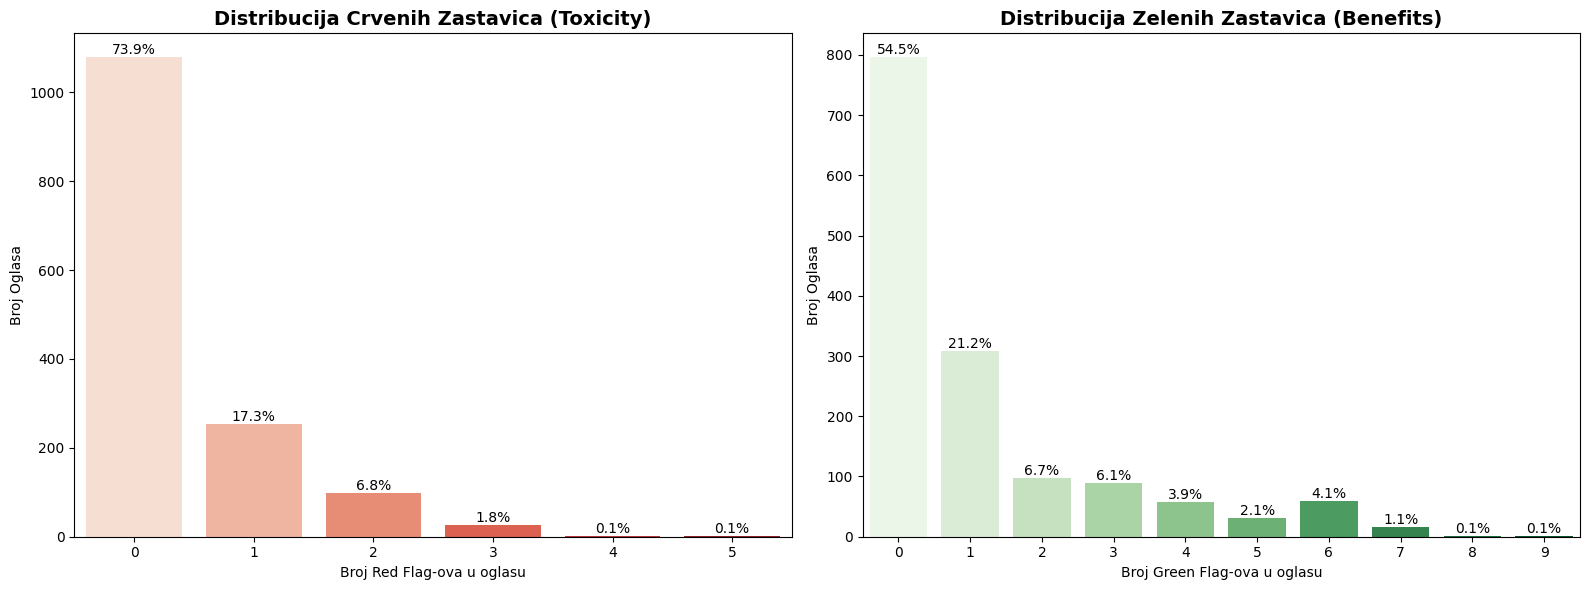

In [ ]:
def get_len(x):
    if isinstance(x, list):
        return len(x)
    if isinstance(x, str):


        try:
            return len(ast.literal_eval(x))
        except:
            return 0
    return 0

df['num_red'] = df['red_flags'].apply(get_len)
df['num_green'] = df['green_flags'].apply(get_len)


total_ads = len(df)
toxic_ads = len(df[df['num_red'] >= 3])
zero_benefit_ads = len(df[df['num_green'] == 0])



fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.countplot(x='num_red', data=df, ax=axes[0], palette='Reds')
axes[0].set_title('Distribucija Crvenih Zastavica (Toxicity)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Broj Red Flag-ova u oglasu')
axes[0].set_ylabel('Broj Oglasa')


total = len(df)
for p in axes[0].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)


sns.countplot(x='num_green', data=df, ax=axes[1], palette='Greens')
axes[1].set_title('Distribucija Zelenih Zastavica (Benefits)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Broj Green Flag-ova u oglasu')
axes[1].set_ylabel('Broj Oglasa')

for p in axes[1].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    axes[1].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

VIZUELNO PRIKAZIVANJE NAKON NORMALIZACIJE

/tmp/ipython-input-1584175566.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(terms), palette=color_palette)


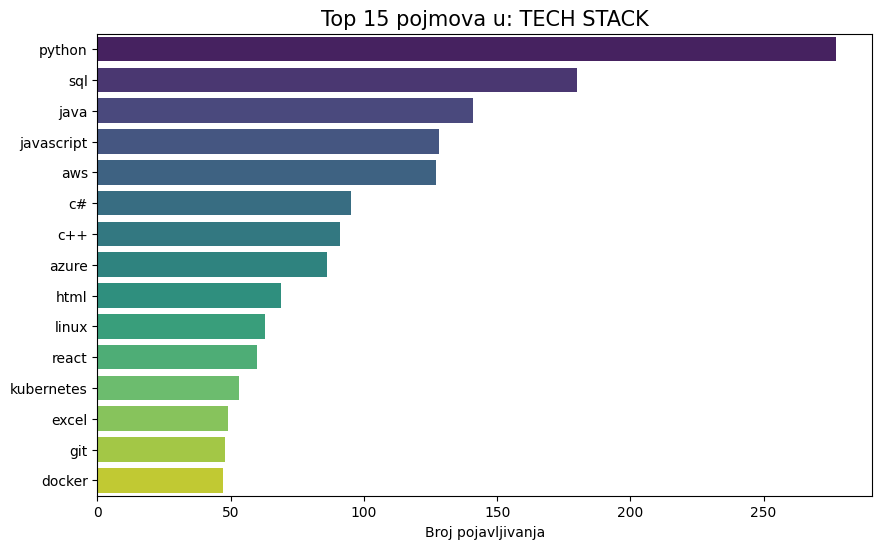

/tmp/ipython-input-1584175566.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(terms), palette=color_palette)


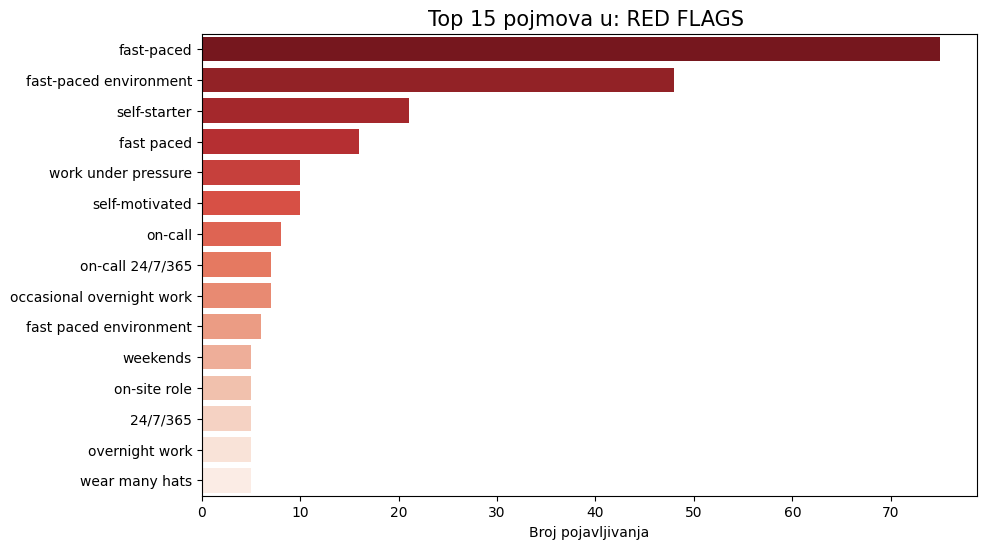

/tmp/ipython-input-1584175566.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(terms), palette=color_palette)


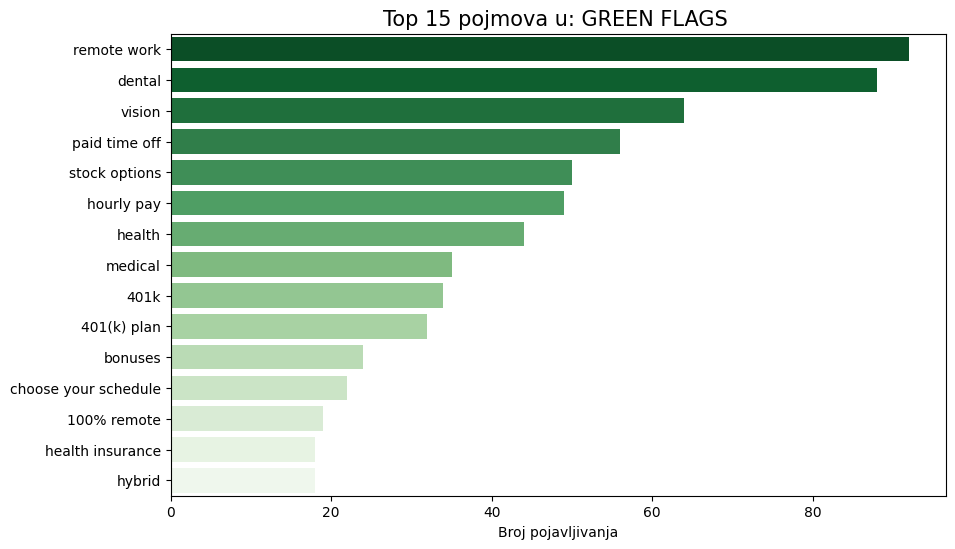

In [ ]:
def plot_top_terms(column_name, title, color_palette):
    all_terms = []
    for item_list in df[column_name]:
        if isinstance(item_list, list):
            all_terms.extend([str(t).lower() for t in item_list])


    counter = Counter(all_terms)
    most_common = counter.most_common(15)


    terms, counts = zip(*most_common)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(terms), palette=color_palette)
    plt.title(f"Top 15 pojmova u: {title}", fontsize=15)
    plt.xlabel("Broj pojavljivanja")
    plt.show()

plot_top_terms('tech_stack', 'TECH STACK', 'viridis')

plot_top_terms('red_flags', 'RED FLAGS ', 'Reds_r')

plot_top_terms('green_flags', 'GREEN FLAGS ', 'Greens_r')

---

##  **KORAK 4: MREŽNA ANALIZA**

### **Mrežna anačiza nam otkriva koje tehnologije se pojavljuju zajedno**


```python
Graf: Python ↔ AWS (weight=65), Python ↔ Django (weight=40)
```

**Otkriva ekosisteme:** Python + AWS + Docker = DevOps stack



---

### **Kreiranje Co-Occurrence Grafa**

**Algoritam:**
```python
for oglas in oglasi:
    tech_list = oglas['tech_stack']
    
    for i in range(len(tech_list)):
        for j in range(i+1, len(tech_list)):
            edge = (tech_list[i], tech_list[j])
            edge_weights[edge] += 1  
```

**Primer:**
Oglas sa `['Python', 'AWS', 'Docker']` kreira:
- Python ↔ AWS (weight +1)
- Python ↔ Docker (weight +1)
- AWS ↔ Docker (weight +1)

---

### **Filtriranje Šuma: MIN_EDGE_WEIGHT = 6**

 Retke kombinacije ("Python + COBOL") prave noise.

Zadržavamo samo ivice koje se pojavljuju 6+ puta.


---



KREIRANJE GRAFA

In [ ]:
df['tech_stack_normalized'] = df['tech_stack'].apply(
    lambda techs: [normalize_tech(t) for t in techs if normalize_tech(t)]
)


G = nx.Graph()

edge_weights = Counter()

node_frequency = Counter()

for tech_list in df['tech_stack_normalized']:

    node_frequency.update(tech_list)


    for i in range(len(tech_list)):
        for j in range(i+1, len(tech_list)):
            edge = tuple(sorted([tech_list[i], tech_list[j]]))
            edge_weights[edge] += 1

MIN_EDGE_WEIGHT = 6

for (tech1, tech2), weight in edge_weights.items():
    if weight >= MIN_EDGE_WEIGHT:
        G.add_edge(tech1, tech2, weight=weight)

print(f"Graf kreiran")
print(f"   Broj čvorova (tehnologija): {G.number_of_nodes()}")
print(f"   Broj ivica (konekcija): {G.number_of_edges()}")

for node in G.nodes():
    G.nodes[node]['frequency'] = node_frequency.get(node, 0)



Graf kreiran
   Broj čvorova (tehnologija): 116
   Broj ivica (konekcija): 301


---

## **KORAK 5: COMMUNITY DETECTION**


**Primer communitia:**  
DevOps tehnologije (Docker, Kubernetes, AWS) se često pojavljuju zajedno, ali retko sa Data Science tehnologijama (Pandas, PyTorch).

---

### **Louvain Algoritam**

- Brz (O(n log n))
- Ne zahteva unapred određen broj klastera
- Optimizuje Modularity (Q score)

**Kako radi:**
1. Svaki čvor kreće u svom klasteru
2. Za svaki čvor: "Da li Q raste ako ga prebacim u susedov klaster?"
3. Ako DA → Prebaci
4. Ponavlja dok se Q poboljšava

---

### **U prvom runu smo imali netehničke klastere, pa zato radimo čišćenje**


---

### **Čišćenje: JUNK_TECH Blacklist**
```python
JUNK_TECH = {
    'HVAC', 'ELECTRICAL', 'PLUMBING', 'WELDING',
    'COMPUTER SCIENCE',
    'MICROSOFT OFFICE SUITE'
}

G.remove_nodes_from(JUNK_TECH)
```

**Takođe:** Synonym normalizacija
```python
SYNONYM_MAP = {
    'NODEJS': 'NODE.JS',
    'POSTGRES': 'POSTGRESQL'
}
```

---
### **Dodavanje Community Atributa Čvorovima**
```python
partition = {}
for i, community in enumerate(communities):
    for node in community:
        partition[node] = i

nx.set_node_attributes(G, partition, 'community')
```

Omogućava kasnije bojenje čvorova po klasteru u vizualizacijama.

---

In [ ]:
communities = nx.community.louvain_communities(G, weight='weight')

partition = {}
for i, community in enumerate(communities):
    for node in community:
        partition[node] = i

nx.set_node_attributes(G, partition, 'community')

modularity_score = nx.community.modularity(G, communities)

print(f"Detektovano {len(communities)} klastera")
print(f"   Modularity Score: {modularity_score:.4f} ")

print("\nČlanovi klastera (Top 10 po veličini):")
communities_sorted = sorted(communities, key=len, reverse=True)
for i, community in enumerate(communities_sorted[:10], 1):
    tech_list = list(community)[:15]
    print(f"   Klaster {i} ({len(community)} tehnologija): {', '.join(tech_list)}")


Detektovano 11 klastera
   Modularity Score: 0.3325 

Članovi klastera (Top 10 po veličini):
   Klaster 1 (38 tehnologija): CSS, PYTHON, JAVASCRIPT, HTML5, TENSORFLOW, PYTORCH, C/C++, C#, .NET CORE, C++, PERL, PL/SQL, JQUERY, SHELL, SPLUNK
   Klaster 2 (23 tehnologija): TYPESCRIPT, ANSIBLE, GOLANG, GCP, NODE.JS, GOOGLE CLOUD, BASH, LAMBDA, KUBERNETES, S3, CLOUDFORMATION, ACTIVE DIRECTORY, RAILS, VMWARE, EC2
   Klaster 3 (23 tehnologija): GO, UNIX, REST, TESTNG, NOSQL, CONFLUENCE, HIVE, XML, WINDOWS, SPRING BOOT, SPARK, KAFKA, SCALA, JSON, JAVA
   Klaster 4 (8 tehnologija): GREAT PLAINS, POWERPOINT, MICROSOFT OFFICE, MICROSOFT OFFICE SUITE, OUTLOOK, WORD, EXCEL, POWER BI
   Klaster 5 (5 tehnologija): HVAC SYSTEMS, UPS UNITS, GENERATORS, NETWORKING, CABLING
   Klaster 6 (4 tehnologija): AUTOMOTIVE, ELECTRICAL, COMPUTER SCIENCE, COMPUTER ENGINEERING
   Klaster 7 (4 tehnologija): ETHERNET PROTOCOL, MULTIMETERS, OSCILLOSCOPES, CAN-BASED COMMUNICATION
   Klaster 8 (3 tehnologija): MACHINE LE

Izbacivanje loše prepoznatih tehnologija, i nromalizacija naziva

In [ ]:
JUNK_TECH = {
    'ELECTRICAL SYSTEMS', 'GENERATORS', 'HVAC SYSTEMS', 'UPS UNITS', 'CABLING',
    'PREVENTATIVE MAINTENANCE', 'CALIBRATIONS', 'EQUIPMENT', 'REPAIRS',
    'PROTOCOLS', 'PLUMBING', 'LIFTING', 'DRIVING', 'OSHA', 'WELDING',
    'PNEUMATIC CONTROLS', 'MOTOR CONTROLLER', 'AIR HANDLING EQUIPMENT',

    'COMPUTER SCIENCE', 'ELECTRICAL', 'AUTOMOTIVE', 'MECHANICAL', 'COMPUTER ENGINEERING',
    'SOFTWARE ENGINEERING', 'CIVIL ENGINEERING',
    'MULTIMETERS', 'ETHERNET PROTOCOL', 'CAN-BASED COMMUNICATION', 'OSCILLOSCOPES', 'NETWORKING', 'GREAT PLAINS', 'MICROSOFT OFFICE SUITE'

    'MEETINGS', 'MEETING', 'COMMUNICATION', 'PLANNING', 'WRITING',
    'DESIGN', 'TESTING', 'DEBUGGING', 'TROUBLESHOOTING', 'MAINTENANCE',
    'DOCUMENTATION', 'CODE REVIEW', 'MENTORING', 'AGILE', 'SCRUM',
    'PROBLEM SOLVING', 'TEAMWORK', 'RELIABLE CODE', 'BUG FIXING',
    'UNIT TESTING', 'INTEGRATION TESTING', 'BEST PRACTICES',

    'MICROSOFT OFFICE', 'EXCEL', 'WORD', 'POWERPOINT', 'OUTLOOK', 'TEAMS',
    'DATA ENTRY', 'TYPING', 'LAPTOP/COMPUTERS SKILLS', 'TICKETING SYSTEMS',
    'ACCESS', 'VISIO', 'SHAREPOINT',

    'CATIA', 'SOLIDWORKS', 'AUTOCAD', 'MATLAB', 'LABVIEW', 'PLC',


    'COMPUTER SCIENCE', 'SOFTWARE ENGINEERING', 'INFORMATION TECHNOLOGY', 'DEGREE'
}


SYNONYM_MAP = {
    'REACTJS': 'REACT', 'REACT.JS': 'REACT',
    'NODEJS': 'NODE.JS', 'NODE': 'NODE.JS',
    'AMAZON WEB SERVICES': 'AWS',
    'POSTGRESQL': 'POSTGRES', 'POSTGRES SQL': 'POSTGRES',
    'GOLANG': 'GO', 'DOTNET': '.NET',
    'NEXTJS': 'NEXT.JS'
}

print(f"Pre čišćenja: {G.number_of_nodes()} čvorova, {G.number_of_edges()} ivica")

G = nx.relabel_nodes(G, SYNONYM_MAP, copy=False)

G.remove_nodes_from(JUNK_TECH)

print(f"Nakon čišćenja: {G.number_of_nodes()} čvorova, {G.number_of_edges()} ivica")


Pre čišćenja: 116 čvorova, 301 ivica
Nakon čišćenja: 91 čvorova, 265 ivica


**COMMUNITY DETECTION** sa očišćenim tehnologijama


In [ ]:


communities = nx.community.louvain_communities(G, weight='weight')

partition = {}
for i, community in enumerate(communities):
    for node in community:
        partition[node] = i

nx.set_node_attributes(G, partition, 'community')

modularity_score = nx.community.modularity(G, communities)

print(f" {len(communities)} čistih IT klastera")
print(f"   Modularity: {modularity_score:.4f}")

for i, community in enumerate(sorted(communities, key=len, reverse=True), 1):
    print(f"   {i}. ({len(community)} tech): {', '.join(list(community)[:8])}")




 7 čistih IT klastera
   Modularity: 0.2751
   1. (31 tech): CSS, PYTHON, JAVASCRIPT, SQL, AJAX, POWERBI, DATADOG, DJANGO
   2. (24 tech): TYPESCRIPT, ANSIBLE, GCP, NODE.JS, GOOGLE CLOUD, LAMBDA, KUBERNETES, BASH
   3. (19 tech): GO, UNIX, REST, TESTNG, NOSQL, HIVE, XML, SPRING BOOT
   4. (10 tech): HTML5, .NET CORE, AZURE DEVOPS, GITHUB, JENKINS, CONFLUENCE, ANGULAR, CSS3
   5. (3 tech): MACHINE LEARNING, AI, ML
   6. (3 tech): ORACLE, SQL SERVER, MYSQL
   7. (1 tech): MICROSOFT OFFICE SUITE



**Validacija Rezultata:**
- Klasteri imaju smisla
- Q (Modularity) = 0.28  
- Najmanji klaster: 1 tech, najveći: 28, u proseku 7 klastera

---



---

## **KORAK 6: CENTRALITY METRIKE**



**Community detection** pokazuje da je "Python je u Data Science klasteru."  

**Centrality metrike** govore koliko je popularan u tom klasteru, i da li povezuje različite klastere.

---

### **Degree Centrality: "Popularnost"**

**Formula:** Broj suseda / Maksimalan mogući broj suseda

**Python:**
```python
degree_centrality = 0.589
# Python je povezan sa 58.9% svih tehnologija u grafu
```

Ove tehnologije su "must-have" skillset - pojavljuju se u svim oblastima.

---

### **Betweenness Centrality: "Most Tehnologije"**

**Formula:** Koliko najkraćih puteva između svih čvorova prolazi kroz dati čvor?

**Interpretacija:** Tehnologija sa visokim betweenness je "most" između različitih tech stackova.

**Python:**
```python
betweenness_centrality = 0.376
# Python povezuje Data Science ↔ DevOps ↔ Backend
```

**Primer:**
Data Scientist koji zna Python može lako da pređe u Backend (Python + Django) ili DevOps (Python + Ansible).


---


In [ ]:
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

nx.set_node_attributes(G, degree_cent, 'degree_centrality')
nx.set_node_attributes(G, betweenness_cent, 'betweenness_centrality')


print("\nTop 10 tehnologija po Degree Centrality (najpovezanije):")
for tech, dc in sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   {tech:25} {dc:.3f}")

print("\nTop 10 tehnologija po Betweenness Centrality ('mostovi' između klastera):")
for tech, bc in sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   {tech:25} {bc:.3f}")




Top 10 tehnologija po Degree Centrality (najpovezanije):
   PYTHON                    0.589
   JAVA                      0.433
   AWS                       0.356
   SQL                       0.278
   JAVASCRIPT                0.256
   AZURE                     0.233
   ANGULAR                   0.211
   DOCKER                    0.189
   C#                        0.178
   REACT                     0.167

Top 10 tehnologija po Betweenness Centrality ('mostovi' između klastera):
   PYTHON                    0.376
   AWS                       0.201
   JAVA                      0.168
   ANGULAR                   0.128
   SQL                       0.109
   REACT                     0.076
   JAVASCRIPT                0.067
   AZURE                     0.060
   JQUERY                    0.051
   POSTGRES                  0.048



### **Praktična Implikacija**

**Za kandidate:**
-  Učenje Python-a otvara vrata u **SVE oblasti** IT-a
- AWS je "passport" za cloud pozicije
- Angular poznavanje omogućava full-stack rad

**Za poslodavce:**
- Python i AWS su najsigurniji skillovi za hiring
- Kandidat sa Python + AWS + SQL može da radi u 5+ različitih tech stackova

---

---

## **KORAK 7: KREIRANJE METRIKA ZA KORELACIONU ANALIZU**

### **Povezujemo Mrežnu Analizu sa Korelacijom?**


### **Metrika 1: `num_communities_covered`**

Pokazuje koliko različitih klastera tehnologije u oglasu pokrivaju.

**Primer:**
```python
Oglas 1: ['Python', 'AWS', 'Docker']
→ Python (Data Science klaster)
→ AWS (DevOps klaster)
→ Docker (DevOps klaster)
→ num_communities_covered = 2 (Data Science + DevOps)

Oglas 2: ['React', 'Node.js', 'MongoDB']
→ Sve iz Web/Frontend klastera
→ num_communities_covered = 1 (specijalizovan)
```

**Hipoteza:** Viši broj → Viša plata

---

### **Metrika 2: `cluster_diversity_ratio`**

**Formula:** `num_communities_covered / num_skills`

Normalizuje za ukupan broj tehnologija.

**Primer:**
```python
Oglas A: 10 tehnologija, 3 klastera → ratio = 0.30
Oglas B: 3 tehnologije, 2 klastera → ratio = 0.67

# Oglas B je "diverzifikovaniji" iako ima manje tehnologija
```

---

### **Metrika 3: `conversion_rate`**

**Formula:** `applies / views`

Originalno smo imali samo 18 oglasa sa oba podakta

Spojili smo dataset sa većim brojem oglasa sa brojem prijava.


---

### **Metrika 4: `net_flags`**

**Formula:** `num_green_flags - num_red_flags`


**Hipoteza:** Pozitivan net_flags → Viši conversion rate


---

In [ ]:
def calculate_cluster_diversity(tech_list):
    clusters_covered = set()
    for tech in tech_list:
        if tech in partition:
            clusters_covered.add(partition[tech])
    return len(clusters_covered)

df['num_communities_covered'] = df['tech_stack_normalized'].apply(calculate_cluster_diversity)
df['num_skills'] = df['tech_stack_normalized'].apply(len)

df['num_red_flags'] = df['red_flags'].apply(len)
df['num_green_flags'] = df['green_flags'].apply(len)

df['conversion_rate'] = df['applies'] / df['views'].replace(0, pd.NA)

df['cluster_diversity_ratio'] = df['num_communities_covered'] / df['num_skills'].replace(0, pd.NA)
df['net_flags'] = df['num_green_flags'] - df['num_red_flags']


df['has_salary'] = df['max_salary'].notna().astype(int)
df['has_views'] = df['views'].notna().astype(int)
df['has_applies'] = df['applies'].notna().astype(int)


print("Sve metrike kreirane")


print("\nNove kolone:")
new_cols = ['num_skills', 'num_communities_covered', 'cluster_diversity_ratio',
            'num_red_flags', 'num_green_flags', 'net_flags', 'vibe_score',
            'conversion_rate', 'has_salary']
print(df[new_cols].describe())


output_path = '/content/drive/MyDrive/ProjekatNAP/FINAL_FOR_CORRELATION.csv'
df.to_csv(output_path, index=False)
print(f"\nFinalni dataset sačuvan: {output_path}")

Sve metrike kreirane

Nove kolone:
        num_skills  num_communities_covered  num_red_flags  num_green_flags  \
count  1460.000000              1460.000000    1460.000000      1460.000000   
mean      4.518493                 0.938356       0.370548         1.137671   
std       4.072215                 1.118249       0.708575         1.762710   
min       0.000000                 0.000000       0.000000         0.000000   
25%       2.000000                 0.000000       0.000000         0.000000   
50%       4.000000                 1.000000       0.000000         0.000000   
75%       6.000000                 2.000000       1.000000         1.000000   
max      34.000000                 5.000000       5.000000         9.000000   

         net_flags   vibe_score  conversion_rate   has_salary  
count  1460.000000  1460.000000       597.000000  1460.000000  
mean      0.767123     6.560274         0.219975     0.333562  
std       1.880024     0.846594         0.125822     0.471647

**GENERALNI GRAFIK**

---

## **KORAK 8: VIZUALIZACIJA - CELA MREŽA (91 TEHNOLOGIJA)**

### **Ponderisana Vizualizacija**

**1. Veličina Čvora = Degree Centrality**
```python
node_sizes = [150 + 1000 * degree_cent[node] for node in G.nodes()]
```
- Python (degree=0.589) → veliki čvor
- Microsoft Office (degree=0.02) → mali čvor

**2. Boja Čvora = Community**
```python
node_colors = [partition[node] for node in G.nodes()]
cmap='tab10'
```

**3. Debljina Ivice = Co-occurrence Weight**
```python
edge_widths = [G[u][v]['weight'] * 0.3 for u, v in G.edges()]
```
- Python ↔ AWS (weight=65) → debela linija
- Python ↔ Fortran (weight=1) → tanka linija (ne bi bila prikazana zbog MIN_EDGE_WEIGHT=6)

**4. Spring Layout (Fruchterman-Reingold)**
```python
pos = nx.spring_layout(G, k=1.5, iterations=100, seed=42)
```

**Parametri:**
- `k=1.5` - Optimalna distanca između čvorova (veće k = više razmaka)
- `iterations=100` - Broj optimizacionih koraka (više = bolje pozicije, sporije)
- `seed=42` - Reproducible results (ista pozicija svaki put)

---

### **5. Selektivno Label-ovanje**

Prikazujemo samo TOP tehnologije (degree > 0.03)
```python
high_degree_nodes = {node: node for node, dc in degree_cent.items()
                     if dc > 0.03}  # ~15-20 tehnologija

nx.draw_networkx_labels(G, pos, labels=high_degree_nodes, font_size=8)
```
---

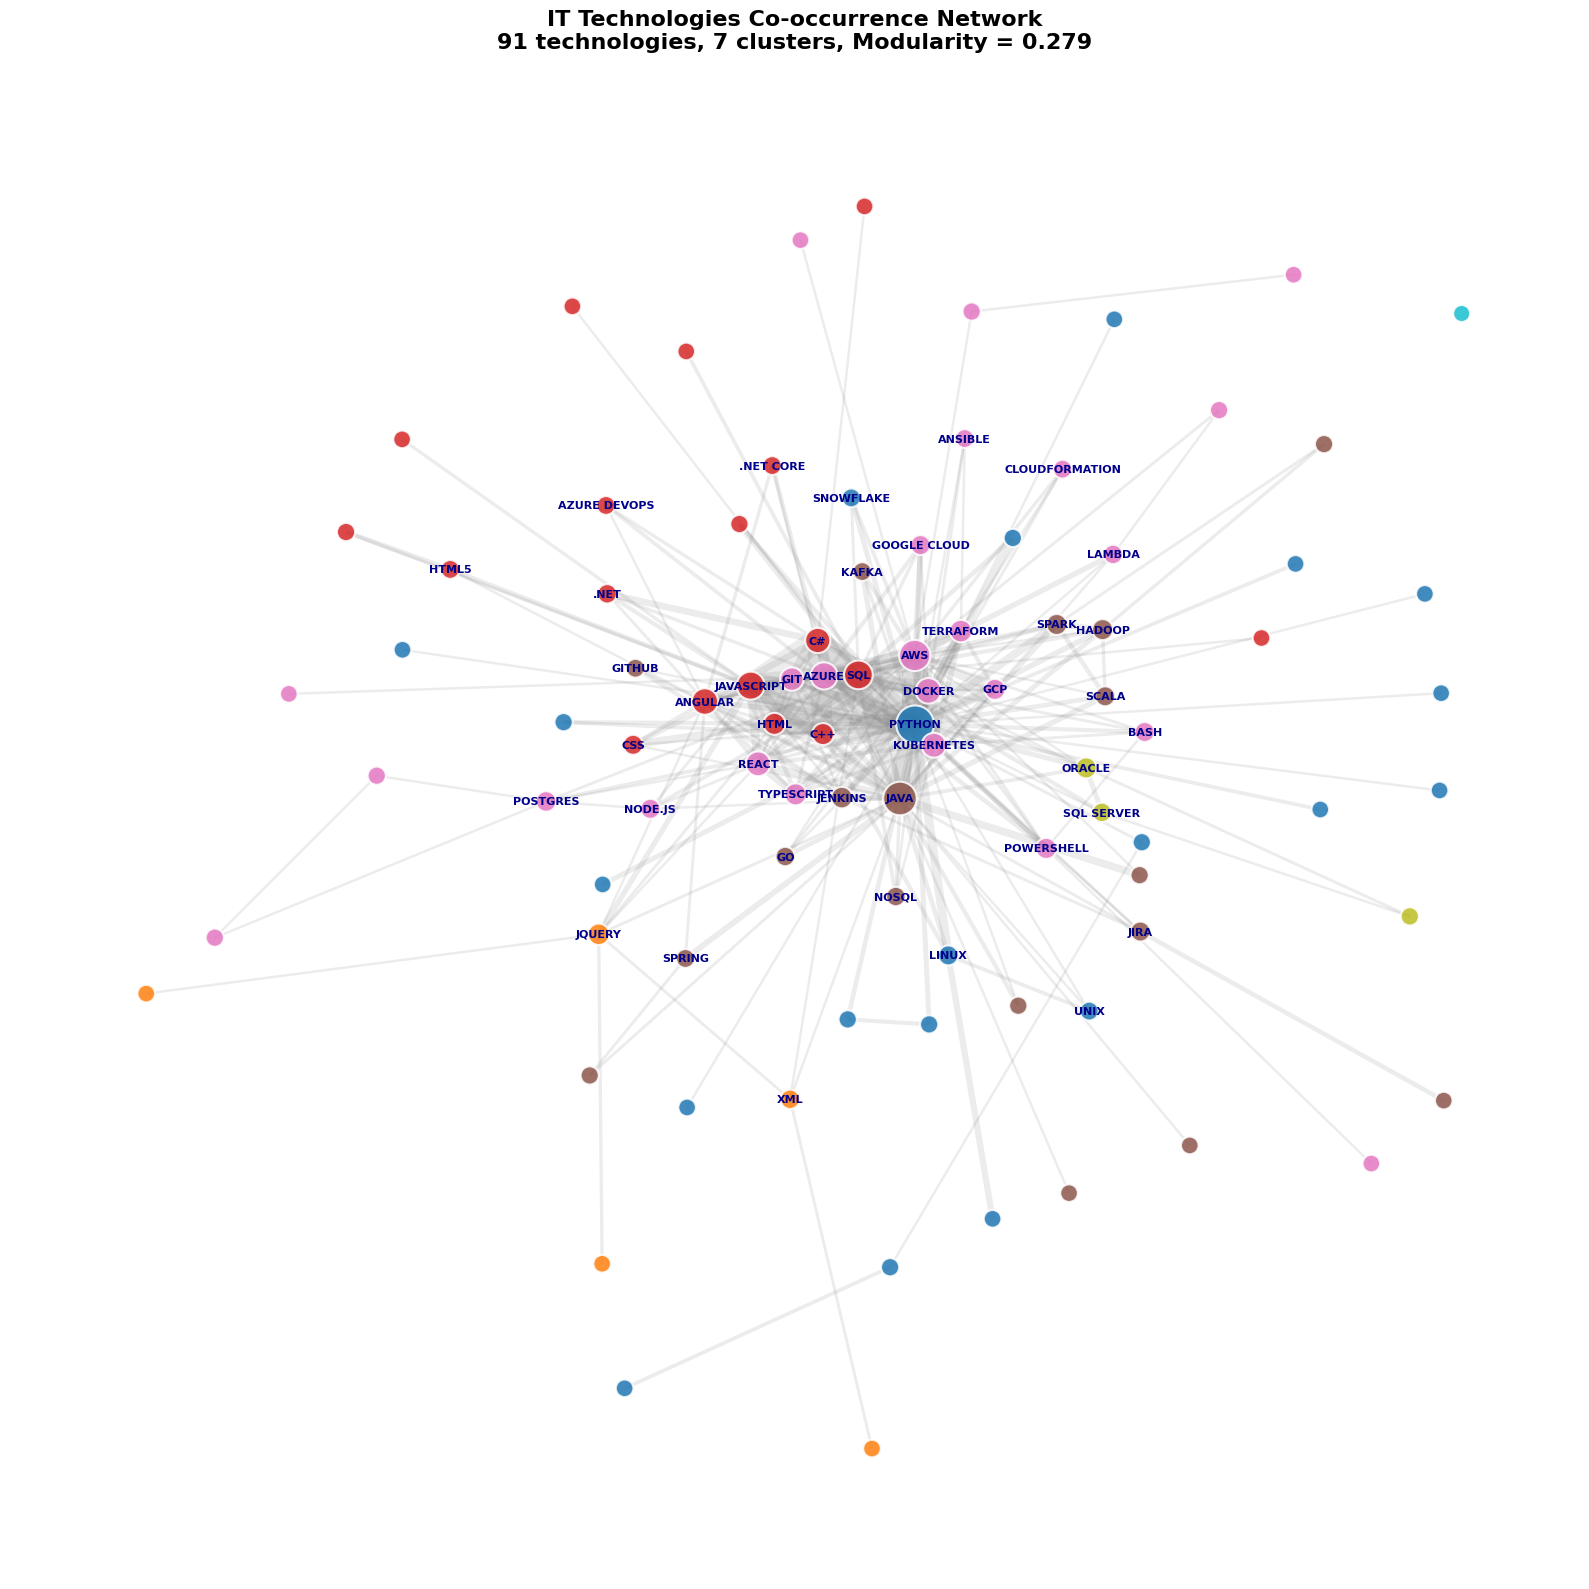

Matplotlib vizualizacija sačuvana!


In [ ]:
warnings.simplefilter('ignore', UserWarning)


node_colors = [partition[node] for node in G.nodes()]
node_sizes = [150 + 1000 * degree_cent[node] for node in G.nodes()]
edge_widths = [G[u][v]['weight'] * 0.3 for u, v in G.edges()]

# Layout algoritam (spring = Fruchterman-Reingold)
pos = nx.spring_layout(G, k=1.5, iterations=100, seed=42)


plt.figure(figsize=(16, 16))

nx.draw_networkx_nodes(G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       cmap='tab10',
                       alpha=0.85,
                       edgecolors='white',
                       linewidths=1.5)

nx.draw_networkx_edges(G, pos,
                       width=edge_widths,
                       alpha=0.15,
                       edge_color='gray')

high_degree_nodes = {node: node for node, dc in degree_cent.items()
                     if dc > 0.03 and node in G.nodes()}

nx.draw_networkx_labels(G, pos,
                        labels=high_degree_nodes,
                        font_size=8,
                        font_weight='bold',
                        font_color='darkblue')

plt.title(f"IT Technologies Co-occurrence Network\n"
          f"{G.number_of_nodes()} technologies, {len(communities)} clusters, "
          f"Modularity = {modularity_score:.3f}",
          fontsize=16, fontweight='bold', pad=20)

plt.axis('off')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/ProjekatNAP/tech_network_matplotlib.png',
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


---

## **KORAK 9: FOKUSIRANI GRAF - TOP 50 NAJČEŠĆIH TEHNOLOGIJA**



### **Kreiranje Subgrafa**
```python
top_techs = sorted(G.nodes(),
                   key=lambda n: G.nodes[n]['frequency'],
                   reverse=True)[:50]

G_top50 = G.subgraph(top_techs).copy()
```

---

### **Re-run Community Detection**

Ponavljamo proces jer sa manje tehnologija, one pripadadaju drugim klasterima.

```python
communities_sub = nx.community.louvain_communities(G_top50, weight='weight')
```

**Rezultat:** Čistija klaster struktura - Python može biti u "Universal" klasteru ako povezuje sve oblasti.

---

### **Veći Node Size**
```python
node_sizes = [300 + 2000 * degree_cent_sub[node]]
```

---

### **Sve Labele Prikazane**
```python
nx.draw_networkx_labels(G_top50, pos, font_size=11)
```


---

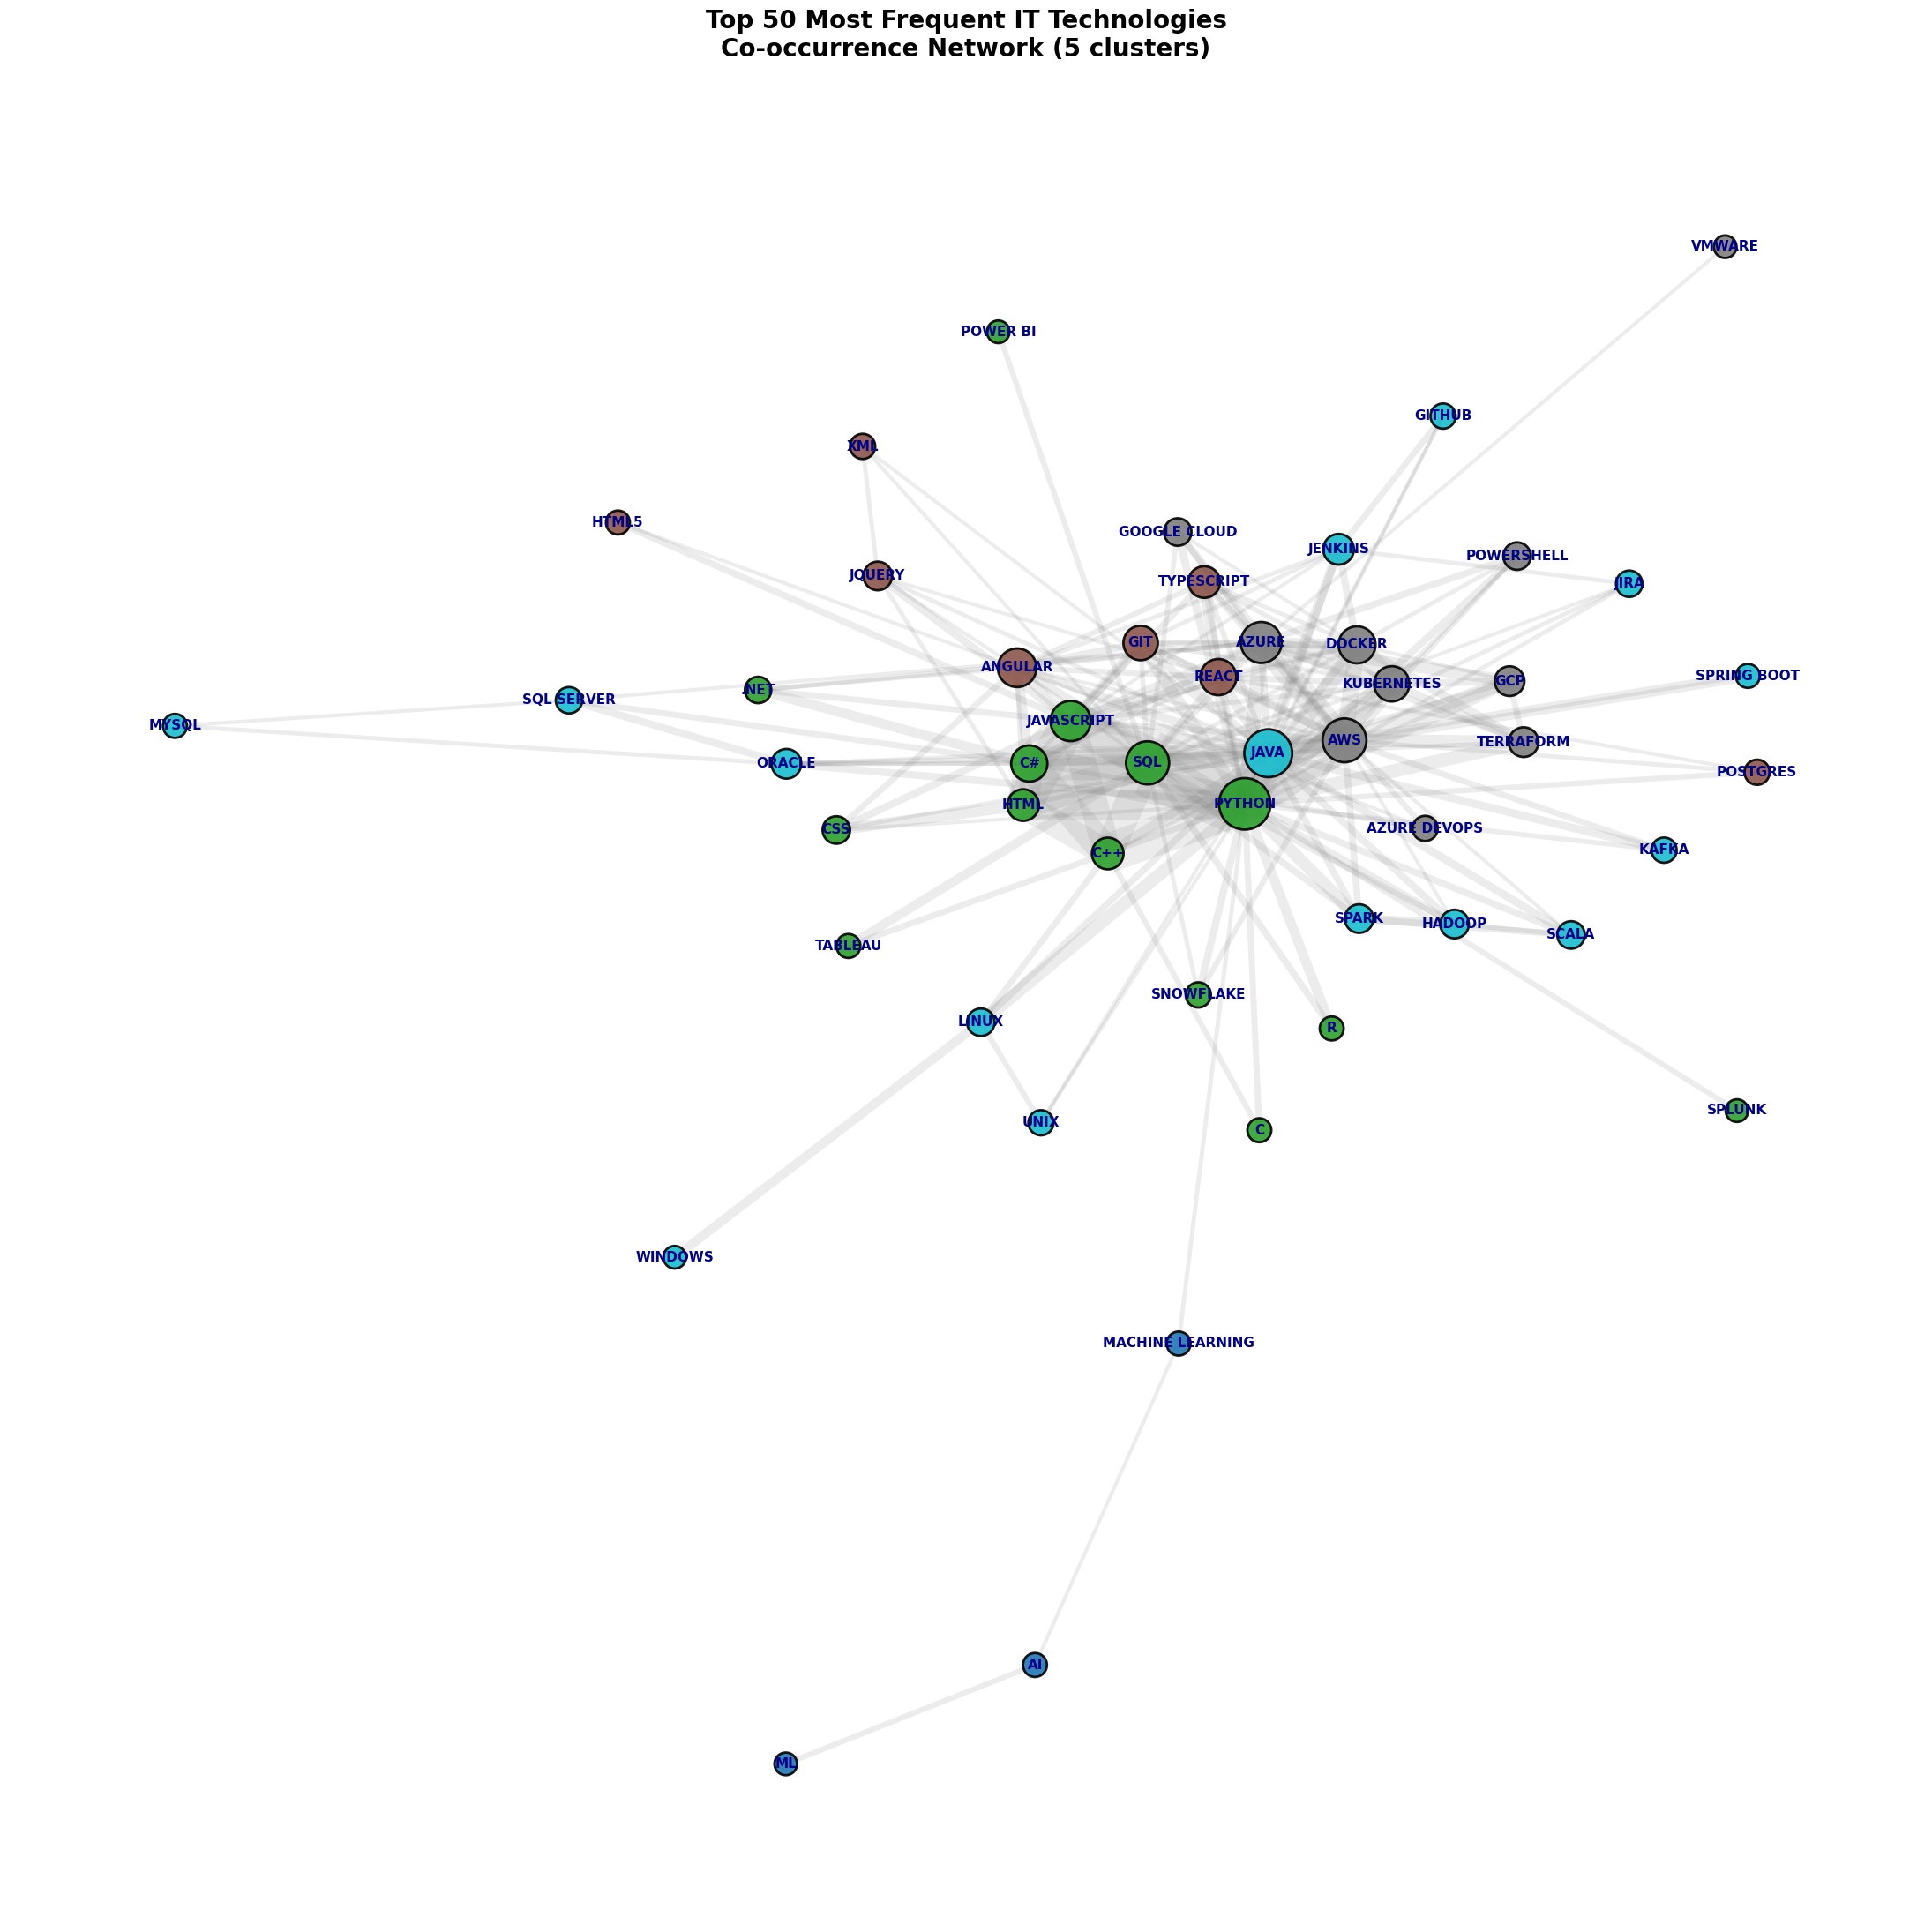

Top 50 (v2) - sa većim razmakom!


In [ ]:

top_techs = sorted(G.nodes(),
                   key=lambda n: G.nodes[n]['frequency'],
                   reverse=True)[:50]

G_top50 = G.subgraph(top_techs).copy()

# Re-run community detection
communities_sub = nx.community.louvain_communities(G_top50, weight='weight')
partition_sub = {}
for i, community in enumerate(communities_sub):
    for node in community:
        partition_sub[node] = i

degree_cent_sub = nx.degree_centrality(G_top50)

node_colors = [partition_sub[node] for node in G_top50.nodes()]
node_sizes = [300 + 2000 * degree_cent_sub[node] for node in G_top50.nodes()]
edge_widths = [G_top50[u][v]['weight'] * 0.5 for u, v in G_top50.edges()]

pos = nx.spring_layout(G_top50, k=1.5, iterations=100, seed=42)

plt.figure(figsize=(22, 22))

nx.draw_networkx_nodes(G_top50, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       cmap='tab10',
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=2)

nx.draw_networkx_edges(G_top50, pos,
                       width=edge_widths,
                       alpha=0.15,
                       edge_color='gray')

nx.draw_networkx_labels(G_top50, pos,
                        font_size=11,
                        font_weight='bold',
                        font_color='darkblue',
                        horizontalalignment='center')

plt.title(f"Top 50 Most Frequent IT Technologies\n"
          f"Co-occurrence Network ({len(communities_sub)} clusters)",
          fontsize=20, fontweight='bold', pad=25)

plt.axis('off')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/ProjekatNAP/tech_network_top50_v2.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Top 50 (v2) - sa većim razmakom!")

---

## **KORAK 10: TOP 4 KLASTERA - DUBINSKA ANALIZA SVAKI POSEBNO**



### **4 Subplot-a, Svaki = 1 Klaster**
```python
top_clusters = sorted(communities, key=len, reverse=True)[:4]
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
```

**Layout: 1 red, 4 kolone**
- Subplot 1: DevOps/Cloud
- Subplot 2: Data Science
- Subplot 3: Web/Frontend
- Subplot 4: Backend/Enterprise

---

### **Kamada-Kawai Layout (Umesto Spring)**



**Spring Layout:**
- Optimizovan za velike grafove (100+ čvorova)

**Kamada-Kawai Layout:**
- Optimizovan za male/srednje grafove

```python
pos_cluster = nx.kamada_kawai_layout(G_cluster, weight='weight')
```

---

### **Labela klastera po keywordovima**

---

### **Veličina Čvora = Frequency u Oglasima**
```python
node_sizes = [400 + 60 * G_cluster.nodes[n]['frequency']]
```

---

### **Transparentne Ivice**
```python
edge_widths = [G_cluster[u][v]['weight'] * 0.6]
alpha=0.2  
```

---

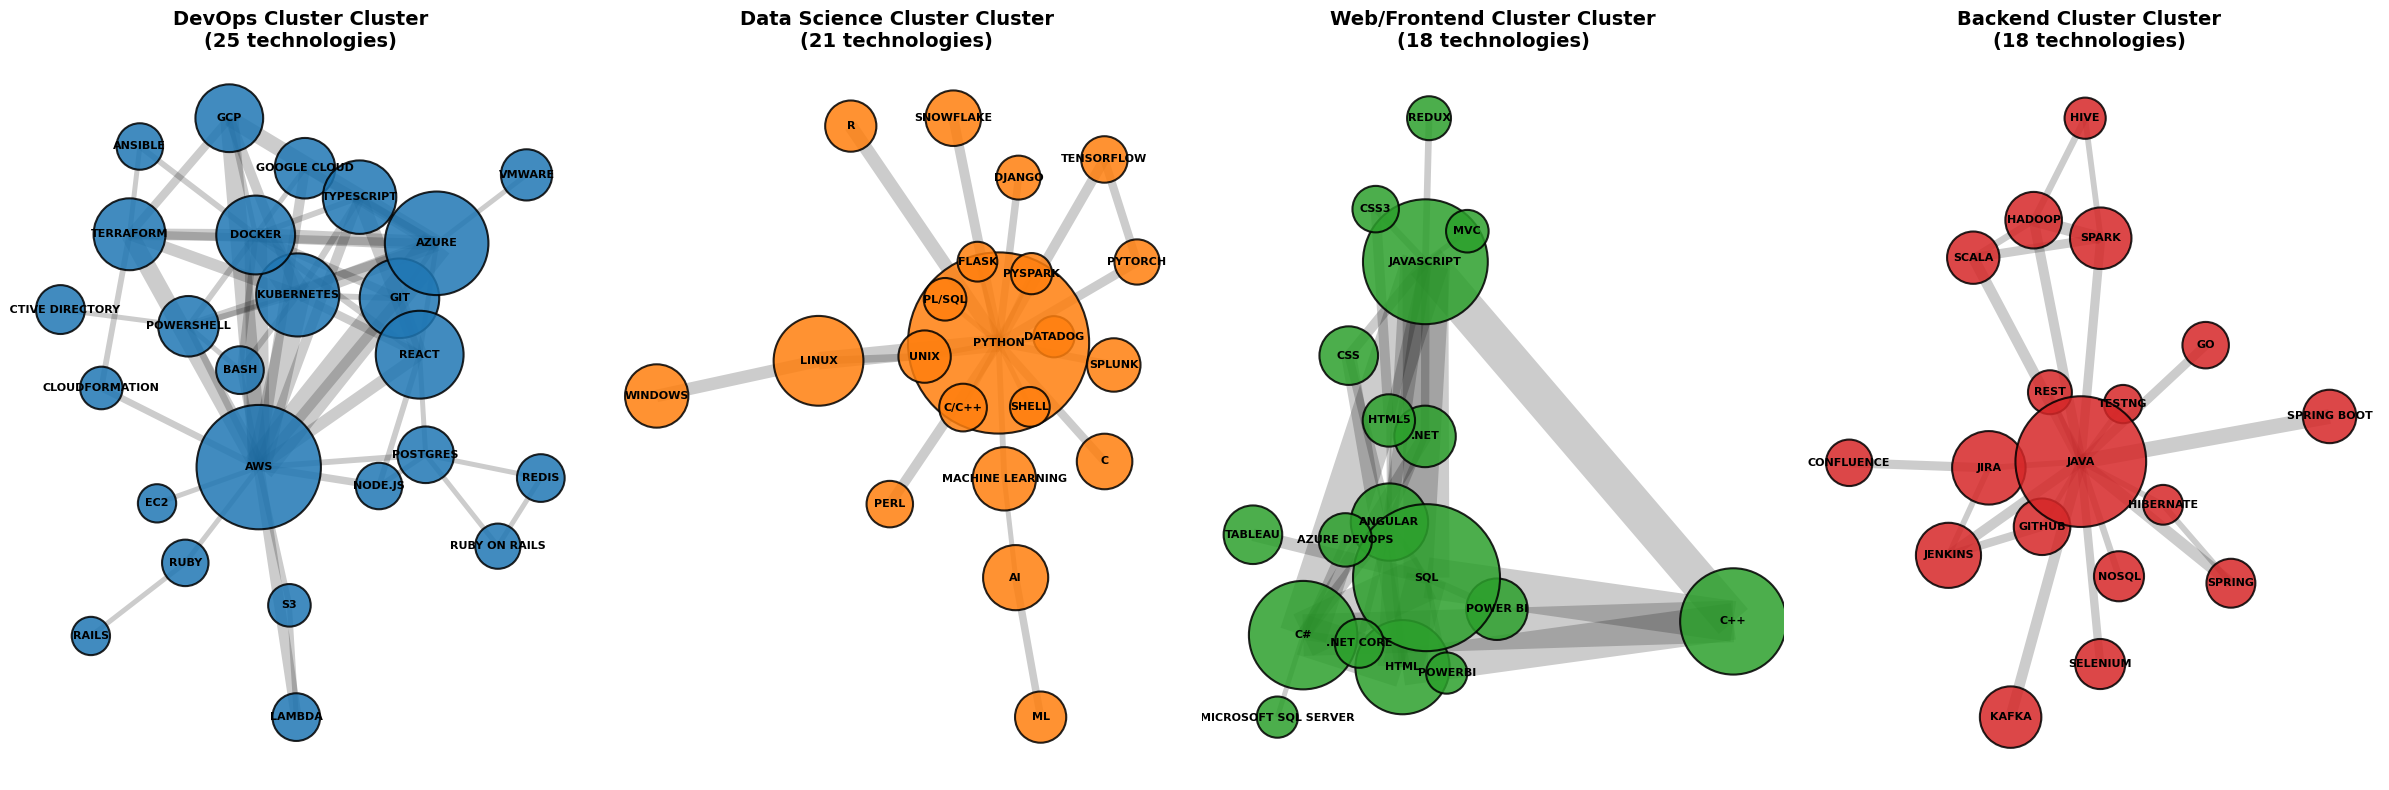

Top 4 klastera (v2) - Kamada-Kawai layout!


In [ ]:

top_clusters = sorted(communities, key=len, reverse=True)[:4]

fig, axes = plt.subplots(1, 4, figsize=(24, 8))

def get_simple_label(cluster):

    text_content = str(cluster).upper()

    # Pitas redom:
    if 'AWS' in text_content or 'DOCKER' in text_content:
        return "DevOps Cluster"

    elif 'PYTHON' in text_content or 'PANDAS' in text_content:
        return "Data Science Cluster"

    elif 'REACT' in text_content or 'ANGULAR' in text_content:
        return "Web/Frontend Cluster"

    elif 'JAVA' in text_content and 'REST' in text_content:
        return "Backend Cluster"


for idx, (cluster, ax) in enumerate(zip(top_clusters, axes)):

    G_cluster = G.subgraph(cluster).copy()

    name = get_simple_label(cluster)


    pos_cluster = nx.kamada_kawai_layout(G_cluster, weight='weight')

    node_sizes_cluster = [400 + 60 * G_cluster.nodes[n]['frequency']
                          for n in G_cluster.nodes()]
    edge_widths_cluster = [G_cluster[u][v]['weight'] * 0.6
                           for u, v in G_cluster.edges()]

    nx.draw_networkx_nodes(G_cluster, pos_cluster,
                          node_size=node_sizes_cluster,
                          node_color=f'C{idx}',
                          alpha=0.85,
                          edgecolors='black',
                          linewidths=1.5,
                          ax=ax)

    nx.draw_networkx_edges(G_cluster, pos_cluster,
                          width=edge_widths_cluster,
                          alpha=0.2,
                          ax=ax)

    nx.draw_networkx_labels(G_cluster, pos_cluster,
                           font_size=8,
                           font_weight='bold',
                           horizontalalignment='center',
                           ax=ax)

    ax.set_title(f"{name} Cluster\n({len(cluster)} technologies)",
                 fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ProjekatNAP/tech_clusters_detail_v2.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



---

## **KORAK 11: CORE TECHNOLOGIES - MOSTOVI IZMEĐU KLASTERA**


Primer:
- Data Science tim koristi Python + Pandas
- DevOps tim koristi Python + Ansible
- Backend tim koristi Python + Django

Python im omogućava da sarađuju.


---

### **Betweenness Centrality Threshold**
```python
hub_threshold = 0.02
hub_nodes = [node for node, bc in betweenness_cent.items()
             if bc > hub_threshold]
```

**betweenness > 0.02**

Tehnologija leži na 2%+ svih najkraćih puteva između svih parova čvorova.

Ova tehnologija je kritična za povezivanje različitih delova tech stack-a.

---

### **Veličina Čvora = Betweenness**
```python
node_sizes = [500 + 3000 * betweenness_cent[n] for n in G_hubs.nodes()]
```
Biramo betweenes jer:

Degree: "Sa koliko tehnologija je Python povezan?"

Betweenness: "Koliko često Python mora biti korišćen da poveže dve različite oblasti?"

**Primer:**
- Python: degree=0.589, betweenness=0.376 → Ogroman čvor (most)
- SQL: degree=0.278, betweenness=0.109 → Srednji čvor (manje kritičan most)

---

### **Deblje Ivice**
```python
edge_widths = [G_hubs[u][v]['weight'] * 0.8]
```
Python ↔ AWS (weight=65) → Vrlo debela linija → Ove dve tehnologije MORAJU da idu zajedno u DevOps/Data stackovima

---

### **Interpretacija**

> "Učenje ovih tehnologija maksimizuje  mobilnost između projekata i kompanija."


---

Hub graf: 19 ključnih tehnologija


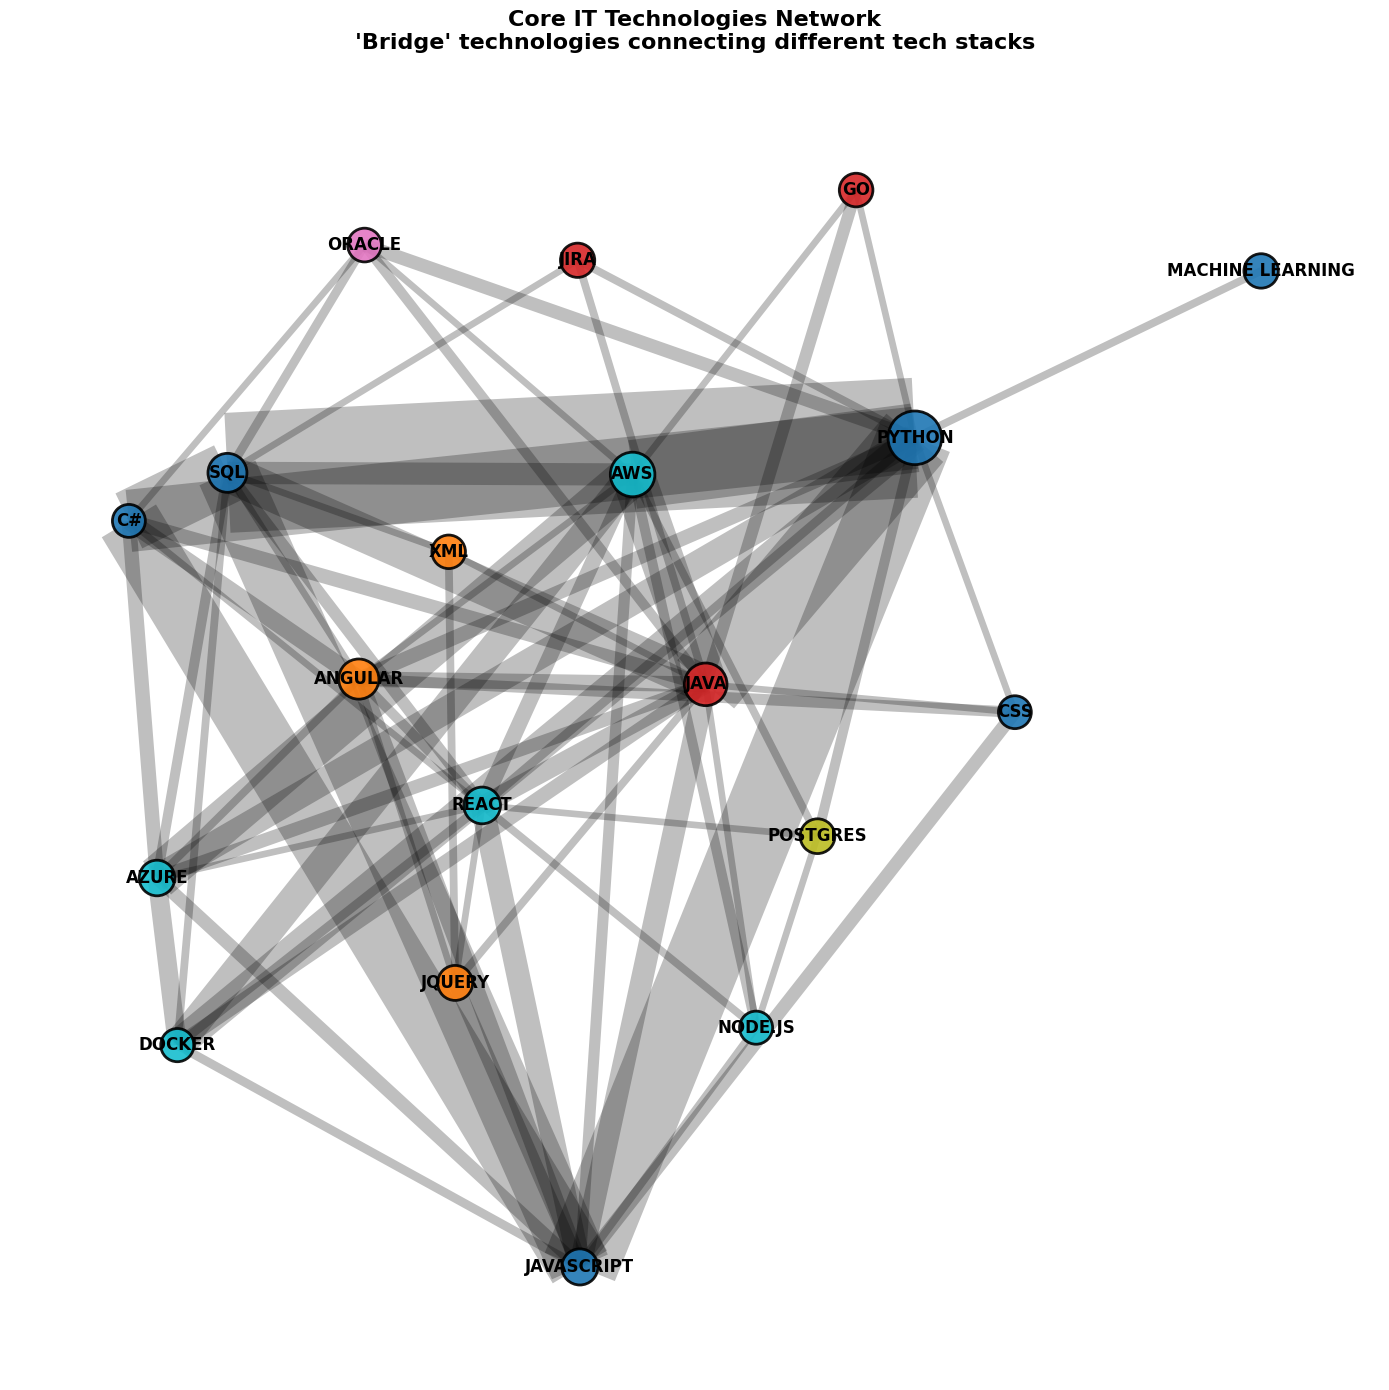

Hub vizualizacija gotova!


In [ ]:

hub_threshold = 0.02
hub_nodes = [node for node, bc in betweenness_cent.items()
             if bc > hub_threshold and node in G.nodes()]

G_hubs = G.subgraph(hub_nodes).copy()

print(f"Hub graf: {G_hubs.number_of_nodes()} ključnih tehnologija")


partition_hubs = {n: partition[n] for n in G_hubs.nodes()}

plt.figure(figsize=(14, 14))

pos_hubs = nx.kamada_kawai_layout(G_hubs, weight='weight')

node_colors_hubs = [partition_hubs[n] for n in G_hubs.nodes()]
node_sizes_hubs = [500 + 3000 * betweenness_cent[n] for n in G_hubs.nodes()]
edge_widths_hubs = [G_hubs[u][v]['weight'] * 0.8 for u, v in G_hubs.edges()]

nx.draw_networkx_nodes(G_hubs, pos_hubs,
                       node_size=node_sizes_hubs,
                       node_color=node_colors_hubs,
                       cmap='tab10',
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=2)

nx.draw_networkx_edges(G_hubs, pos_hubs,
                       width=edge_widths_hubs,
                       alpha=0.25)

nx.draw_networkx_labels(G_hubs, pos_hubs,
                        font_size=12,
                        font_weight='bold')

plt.title(f"Core IT Technologies Network\n"
          f"'Bridge' technologies connecting different tech stacks",
          fontsize=16, fontweight='bold', pad=20)

plt.axis('off')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/ProjekatNAP/tech_network_hubs.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



INTERAKTIVNA VIZUELIZACIJA

---

## **KORAK 12: INTERAKTIVNA VIZUALIZACIJA - EKSPLORATORNA ANALIZA**


### **PyVis: Web-Based Interaktivna Vizualizacija**

**Output:** HTML fajl koji se otvara u browseru.

**Mogućnosti:**
1. **Zoom in/out**
2. **Drag nodes**
3. **Hover tooltips**
4. **Click highlighting**
5. **Search**

---

### **Tooltip Metadata**
```python
node['title'] = (f"<b>{node_id}</b><br>"
                 f"Cluster: {cluster_id + 1}<br>"
                 f"Degree: {degree_cent[node_id]:.3f}<br>"
                 f"Betweenness: {betweenness_cent[node_id]:.3f}<br>"
                 f"Frequency: {G.nodes[node_id]['frequency']}")
```
Primer:
**Hover nad "Python"**
```
Python
Cluster: 2
Degree: 0.589
Betweenness: 0.376
Frequency: 277
```


### **ForceAtlas2 Fizika**
```python
"solver": "forceAtlas2Based"
```

**Parametri:**
```python
"gravitationalConstant": -50
"springLength": 200          
"springConstant": 0.05      
```

---



### **Performanse**
```python
"stabilization": {"iterations": 150}
```

Fizika engine prvo simulira 150 iteracija **pre nego što prikaže graf**.




---

### **File Output:**
```
tech_network_interactive.html (2.5 MB)
```


---

In [ ]:
net = Network(height='900px',
              width='100%',
              bgcolor='#1a1a1a',
              font_color='white',
              notebook=True)

net.from_nx(G)

cluster_colors = [
    '#e74c3c',  # Crvena
    '#3498db',  # Plava
    '#2ecc71',  # Zelena
    '#f39c12',  # Narandžasta
    '#9b59b6',  # Ljubičasta
    '#1abc9c',  # Tirkizna
    '#34495e',  # Siva
    '#e67e22'   # Tamno narandžasta
]

for node in net.nodes:
    node_id = node['id']

    cluster_id = partition[node_id]
    node['color'] = cluster_colors[cluster_id % len(cluster_colors)]

    node['size'] = 10 + degree_cent[node_id] * 100

    node['title'] = (f"<b>{node_id}</b><br>"
                     f"Cluster: {cluster_id + 1}<br>"
                     f"Degree Centrality: {degree_cent[node_id]:.3f}<br>"
                     f"Betweenness: {betweenness_cent[node_id]:.3f}<br>"
                     f"Frequency: {G.nodes[node_id]['frequency']}")

    node['label'] = node_id
    node['font'] = {'size': 12, 'color': 'white'}

for edge in net.edges:
   for edge in net.edges:
    weight = edge.get('weight', 1)

    edge['width'] = weight * 0.5
    edge['color'] = {'color': 'rgba(150,150,150,0.3)', 'highlight': 'yellow'}

net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 200,
      "springConstant": 0.05,
      "avoidOverlap": 0.8
    },
    "maxVelocity": 50,
    "minVelocity": 0.1,
    "solver": "forceAtlas2Based",
    "timestep": 0.35,
    "stabilization": {"iterations": 150}
  },
  "interaction": {
    "hover": true,
    "tooltipDelay": 100,
    "navigationButtons": true,
    "keyboard": true
  }
}
""")

output_path = '/content/drive/MyDrive/ProjekatNAP/tech_network_interactive.html'
net.show(output_path)

print(f"PyVis interaktivna vizualizacija sačuvana: {output_path}")


/content/drive/MyDrive/ProjekatNAP/tech_network_interactive.html
PyVis interaktivna vizualizacija sačuvana: /content/drive/MyDrive/ProjekatNAP/tech_network_interactive.html


---

## **KORAK 13: PERSISTENTNOST - ČUVANJE GRAFA ZA BUDUĆE ANALIZE**

### **Čuvamo graf pomoću picklea, radi budućih analiza**


**čuvamo:**
- Svi čvorovi (91 tehnologija)
- Sve ivice (265 konekcija + weights)
- Node attributes (frequency, degree_centrality, betweenness, community)
- Edge attributes (weight)

---





In [ ]:
with open('/content/drive/MyDrive/ProjekatNAP/tech_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

with open('/content/drive/MyDrive/ProjekatNAP/partition.pkl', 'wb') as f:
    pickle.dump(partition, f)



---

## **KORAK 14: SPAJANJE SA SALARY PODACIMA**

### **0.9% Coverage u prvobitnom datasetu**

spajamo sa

### **Externím Salary Fajlom**

LinkedIn dataset ima salary tabelu:

**salaries.csv**

---

### **inner JOIN Operacija za spajanje tabela**


---

In [ ]:

base_path = "/content/drive/MyDrive/ProjekatNAP/"
salaries_path = base_path + "salaries.csv"

try:
    df_salaries = pd.read_csv(salaries_path)
    print(f"Učitan salaries.csv: {len(df_salaries)} redova.")
    display(df_salaries.head())
except FileNotFoundError:
    print("Nema salaries.csv na Drive-u. Uploaduj ga!")

df_main = pd.read_csv('/content/drive/MyDrive/ProjekatNAP/FINAL_FOR_CORRELATION.csv')

df_merged = pd.merge(
    df_main,
    df_salaries[['job_id', 'max_salary', 'min_salary', 'pay_period', 'currency']],
    on='job_id',
    how='inner'
)

print(f"\nBroj oglasa koji imaju platu: {len(df_merged)}")


Učitan salaries.csv: 40785 redova.


,salary_id,job_id,max_salary,med_salary,min_salary,pay_period,currency,compensation_type
0,1,3884428798,NaN,20.0,NaN,HOURLY,USD,BASE_SALARY
1,2,3887470552,25.0,NaN,23.0,HOURLY,USD,BASE_SALARY
2,3,3884431523,120000.0,NaN,100000.0,YEARLY,USD,BASE_SALARY
3,4,3884911725,200000.0,NaN,10000.0,YEARLY,USD,BASE_SALARY
4,5,3887473220,35.0,NaN,33.0,HOURLY,USD,BASE_SALARY



Broj oglasa koji imaju platu: 503


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   job_id                   503 non-null    int64  
 1   title                    503 non-null    object 
 2   company                  502 non-null    object 
 3   tech_stack               503 non-null    object 
 4   vibe_score               503 non-null    int64  
 5   red_flags                503 non-null    object 
 6   green_flags              503 non-null    object 
 7   experience               279 non-null    object 
 8   reasoning                503 non-null    object 
 9   max_salary_x             487 non-null    float64
 10  med_salary               16 non-null     float64
 11  remote_allowed           131 non-null    float64
 12  views                    498 non-null    float64
 13  applies                  229 non-null    float64
 14  num_red                  5

---

## **KORAK 15: NORMALIZACIJA PLATA**

### **Normalizujemo plate zbog različitih platnih perioda, i prebacujemo sve na godišnju**




In [ ]:
def normalize_salary(row):
    salary = row['max_salary_x']
    period = str(row['pay_period']).upper()

    if pd.isna(salary):
        return None

    if 'HOUR' in period:
        return salary * 40 * 52
    elif 'MONTH' in period:
        return salary * 12
    elif 'YEAR' in period:
        return salary
    else:
        return salary

df_merged['annual_salary'] = df_merged.apply(normalize_salary, axis=1)

df_clean_salary = df_merged[
    (df_merged['annual_salary'] > 30000) &
    (df_merged['annual_salary'] < 500000)
].copy()

print(f"Nakon čišćenja (validne godišnje plate): {len(df_clean_salary)}")


Nakon čišćenja (validne godišnje plate): 478


---

## **KORELACIONA ANALIZA**

### **Priprema Podataka:**

**Dodane metrike za analizu:**
- `num_communities_covered` - Broj različitih klastera koje tehnologije pokrivaju (0-7)
- `cluster_diversity_ratio` - Diversity / ukupan broj tehnologija
- `num_red_flags`, `num_green_flags` - Brojači za ton oglasa
- `conversion_rate` - applies / views (mera angažovanja)

**Spajanje sa salary podacima:**
- Originalno: 13 oglasa sa platama (0.9%)
- Nakon spajanja sa `salaries.csv`: 478 oglasa (33%)
- Normalizovane godišnje plate (hourly → annual)

---

---

## **KORAK 16: PRVA KORELACIONA ANALIZA - ŠIRINA ZNANJA vs PLATA**

### **Istraživačko Pitanje:**

> "Da li tehnološka raznolikost (poznavanje više različitih oblasti) donosi višu platu?"

**Hipoteza:** Full-stack developeri (poznaju Frontend + Backend + DevOps) zarađuju više od specijalizovanih.

---




/tmp/ipython-input-2729946896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clusters_grouped', y='annual_salary', data=df_clean_salary, order=order, palette="viridis")


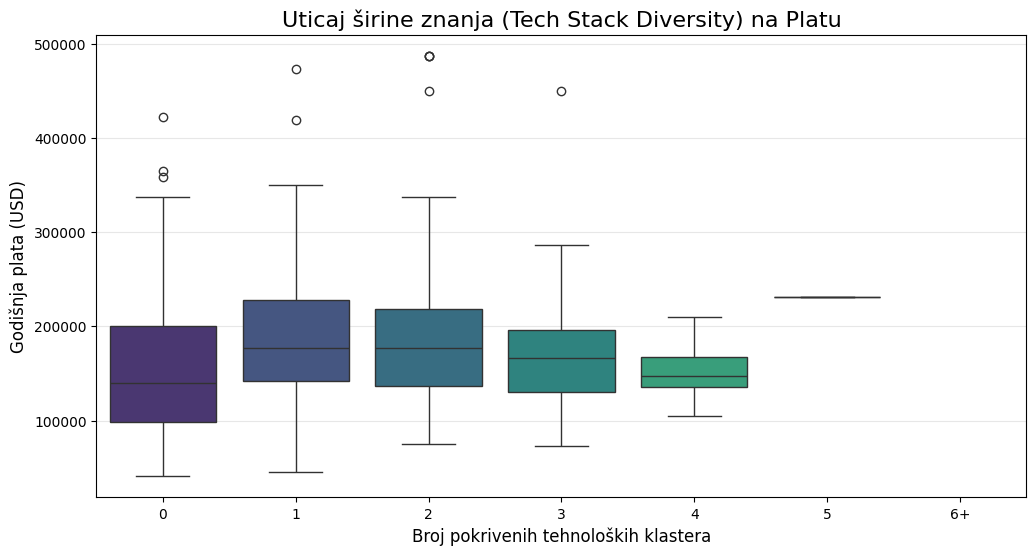


Koeficijent korelacije (Diversity vs Salary): 0.1364


In [ ]:

if len(df_clean_salary) > 50:
    plt.figure(figsize=(12, 6))

    df_clean_salary['clusters_grouped'] = df_clean_salary['num_communities_covered'].apply(lambda x: str(x) if x < 6 else '6+')
    order = ['0', '1', '2', '3', '4', '5', '6+']

    sns.boxplot(x='clusters_grouped', y='annual_salary', data=df_clean_salary, order=order, palette="viridis")

    plt.title('Uticaj širine znanja (Tech Stack Diversity) na Platu', fontsize=16)
    plt.xlabel('Broj pokrivenih tehnoloških klastera', fontsize=12)
    plt.ylabel('Godišnja plata (USD)', fontsize=12)
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

    corr = df_clean_salary['num_communities_covered'].corr(df_clean_salary['annual_salary'])
    print(f"\nKoeficijent korelacije (Diversity vs Salary): {corr:.4f}")

else:
    print("\nI dalje nemamo dovoljno plata (<50)")


### **Rezultat: r = 0.1364**


**Interpretacija:**
- Slaba pozitivna korelacija
---


Pošto najveći skok vidimo izmedju 0 i 1 klastera, proveravamo o čemu se tu radi.
---


---

## **KORAK 17: OTKRIVANJE SKRIVENE POPULACIJE**

### **Cluster 0**
```python
num_communities_covered = 0
```

- **Polovina dataseta** je Cluster 0

---


In [ ]:
zeros = df_clean_salary[df_clean_salary['num_communities_covered'] == 0]

print(f"Ukupno poslova sa 0 klastera: {len(zeros)}")
print(f" {len(zeros) / len(df_clean_salary) * 100:.1f}% dataseta.\n")

print("PRVIH 20 NASLOVA POSLOVA U GRUPI '0 KLASTERA':")
print("-" * 60)
pd.set_option('display.max_colwidth', 100)
print(zeros[['title', 'tech_stack', 'annual_salary']].head(20).to_string(index=False))

Ukupno poslova sa 0 klastera: 253
 52.9% dataseta.

PRVIH 20 NASLOVA POSLOVA U GRUPI '0 KLASTERA':
------------------------------------------------------------
                                                                      title                                                                                      tech_stack  annual_salary
                                                   Senior Software Engineer                                                                  ['Operating System', 'DevOps']       292200.0
                                            Manager, Software Development 2                                                                                              []       234300.0
                                                 Partner Solutions Engineer                                               ['Procore', 'ERP', 'CRM', 'Cloud Infrastructure']       176800.0
                                             Technical Support Analyst - US                 


### **Objašnjenje:**

1. **Generični opisi** - "Operating System", "Cloud Infrastructure" (previše broad termini)
2. **Niche tools** - "ServiceNow", "Procore", "VXretail" (enterprise software ispod MIN_FREQ threshold-a)
3. **Netehničke role** - Project Managers, Technical Writers, Support Analysts


Cluster 0 medijana: $115,000

Cluster 1+ medijana: $135,000

Razlika: $20k (17%)


**Zaključak:** Cluster 0 je većinom **netehničke ili generic pozicije** sa nižom platom. Cela korelacija 0.23 dolazi iz razlike između ove dve populacije, ne iz breadth-a znanja unutar tehničkih pozicija.

---

# Ponavljamo grafik bez 0 klastera

Broj 'pravih' inženjera (Tech > 0): 225


/tmp/ipython-input-4052215175.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_communities_covered', y='annual_salary', data=df_real_engineers, palette="magma")


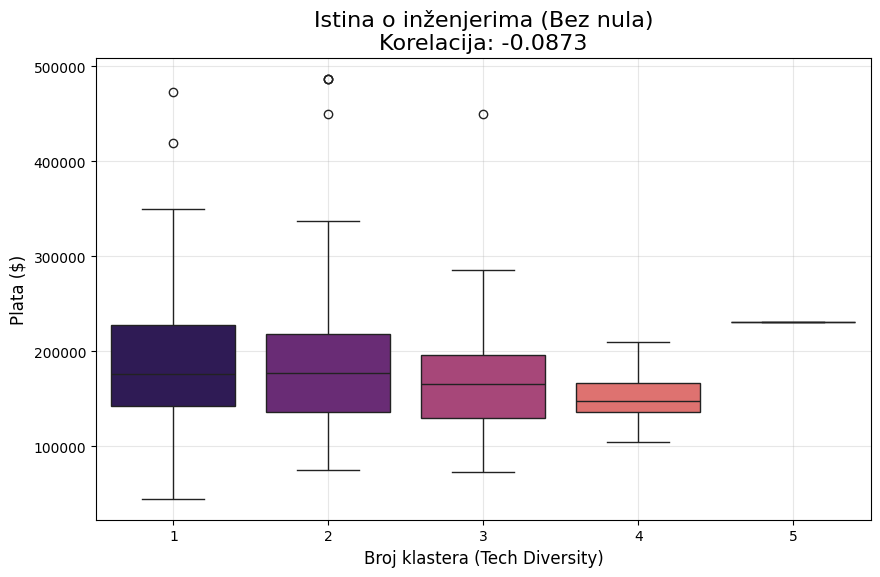


Stara korelacija (sa nulama): 0.1364
Nova korelacija (bez nula):    -0.0873

Sav rast je bio zbog razlike između 'Netehničkih' poslova (0) i 'Tačnih' tehnologija (1) .
Kada gledamo samo programere, širina znanja ne utiče bitno na platu (ili čak smeta).


In [ ]:
df_real_engineers = df_clean_salary[df_clean_salary['num_communities_covered'] > 0].copy()

if len(df_real_engineers) > 30:
    print(f"Broj 'pravih' inženjera (Tech > 0): {len(df_real_engineers)}")

    new_corr = df_real_engineers['num_communities_covered'].corr(df_real_engineers['annual_salary'])

    plt.figure(figsize=(10, 6))

    sns.boxplot(x='num_communities_covered', y='annual_salary', data=df_real_engineers, palette="magma")

    plt.title(f'Istina o inženjerima (Bez nula)\nKorelacija: {new_corr:.4f}', fontsize=16)
    plt.xlabel('Broj klastera (Tech Diversity)', fontsize=12)
    plt.ylabel('Plata ($)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nStara korelacija (sa nulama): {corr:.4f}")
    print(f"Nova korelacija (bez nula):    {new_corr:.4f}")

    if new_corr < 0.1:
        print("\nSav rast je bio zbog razlike između 'Netehničkih' poslova (0) i 'Tačnih' tehnologija (1) .")
        print("Kada gledamo samo programere, širina znanja ne utiče bitno na platu (ili čak smeta).")
else:
    print("Nemamo dovoljno podataka kad izbacimo nule.")

---


Kada eliminišemo netehničke pozicije i fokusiramo se **samo na software engineers/developere**:
```
Stara korelacija (sa nulama): 0.1364
Nova korelacija (bez nula):  -0.0873
```

### **Interpretacija:**

**Pozitivan trend je nestao**


- Ceo rast od 0.14 korelacije dolazio je iz razlike: netehničke ($115k) vs tehničke ($135k) pozicije
- **Unutar tehničkih pozicija**: Generalisti zaradjuju manje ili isto kao specijalizovani


**Zaključak:** Tržište **NE nagrađuje** širinu znanja. Dubina i seniority su važniji.

---

# **GRAFIK ZA POREDJENJE UKUPNOG BROJA VEŠTINA I RASTA PLATE**





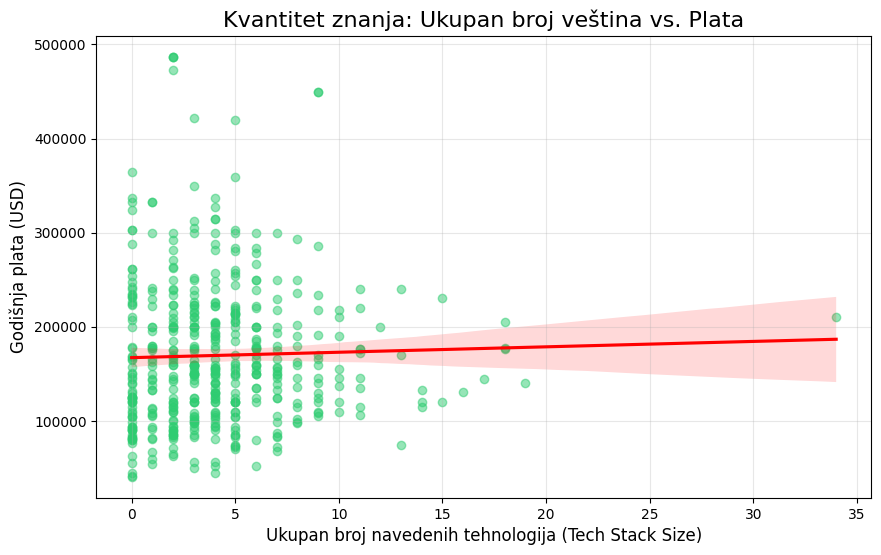

In [ ]:
if len(df_clean_salary) > 50:

    plt.figure(figsize=(10, 6))


    sns.regplot(
        x='num_skills',
        y='annual_salary',
        data=df_clean_salary,
        scatter_kws={'alpha':0.5, 'color':'#2ecc71'},
        line_kws={'color':'red'}
    )

    plt.title('Kvantitet znanja: Ukupan broj veština vs. Plata', fontsize=16)
    plt.xlabel('Ukupan broj navedenih tehnologija (Tech Stack Size)', fontsize=12)
    plt.ylabel('Godišnja plata (USD)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()


---



### **Rezultat:**

Korelacija: 0.0282 (praktično 0)

---

---

## **KORAK 18: KOLIČINA vs ŠIRINA - ŠTA TRŽIŠTE VIŠE CENI?**



---

In [ ]:

corr_diversity_all = df_clean_salary['num_communities_covered'].corr(df_clean_salary['annual_salary'])
new_corr = df_real_engineers['num_communities_covered'].corr(df_real_engineers['annual_salary'])
corr_volume = df_clean_salary['num_skills'].corr(df_clean_salary['annual_salary'])

print(f"1. Širina znanja - SVI OGLASI (Cluster Diversity):      {corr_diversity_all:.4f}")
print(f"2. Širina znanja - SAMO SA TEHNOLOGIJAMA:              {new_corr:.4f}")
print(f"3. Količina alata (Skill Count):                        {corr_volume:.4f}")
print("-" * 60)


THRESHOLD = 0.1

if abs(new_corr) < THRESHOLD and abs(corr_volume) < THRESHOLD:
    print("ZAKLJUČAK: Nijedna tehnička metrika nema presudan uticaj na platu.")

elif new_corr > THRESHOLD and new_corr > corr_volume:
    print("ZAKLJUČAK: Tržište nagrađuje GENERALISTE (Širinu znanja).")
    print("   (Poznavanje više različitih oblasti donosi veću platu nego duboka specijalizacija.)")

elif corr_volume > THRESHOLD and corr_volume > new_corr:
    print("ZAKLJUČAK: Tržište nagrađuje EKSPERTE (Količinu alata).")
    print("   (Poznavanje velikog broja alata unutar jedne oblasti se više isplati.)")

elif new_corr < -THRESHOLD:
    print("ZAKLJUČAK: Tržište blago kažnjava svaštarenje.")
    print("   (Negativna korelacija sugeriše da usko specijalizovane role imaju viši plafon zarade.)")

else:
    print("ZAKLJUČAK: Uticaj je mešovit. Obe metrike blago doprinose, ali nema jasnog pobednika.")


1. Širina znanja - SVI OGLASI (Cluster Diversity):      0.1364
2. Širina znanja - SAMO SA TEHNOLOGIJAMA:              -0.0873
3. Količina alata (Skill Count):                        0.0282
------------------------------------------------------------
ZAKLJUČAK: Nijedna tehnička metrika nema presudan uticaj na platu.


---

## **KORAK 19: DA LI TON OGLASA UTIČE NA BROJ APLIKACIJA?**


In [ ]:

df_engagement = df[df['views'].notna() & df['applies'].notna()].copy()

print(f"\nDataset za analizu: {len(df_engagement)} oglasa")
print(f"   Sa conversion_rate: {df_engagement['conversion_rate'].notna().sum()}")



Dataset za analizu: 597 oglasa
   Sa conversion_rate: 597


# HIPOTEZA 1: Red Flags → Manji Conversion Rate

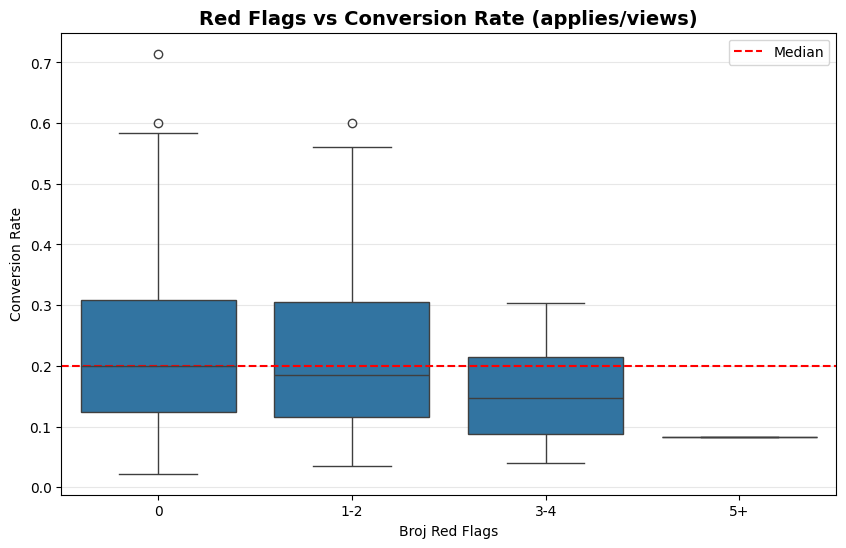


Korelacija (Red Flags vs Conversion): -0.0949

T-test:
   SA red flags: mean = 0.208, n = 149
   BEZ red flags: mean = 0.224, n = 448
   p-value: 0.1887 Nije značajno


In [ ]:
df_engagement['red_flags_grouped'] = df_engagement['num_red_flags'].apply(
    lambda x: '0' if x == 0 else '1-2' if x <= 2 else '3-4' if x <= 4 else '5+'
)

plt.figure(figsize=(10, 6))
order = ['0', '1-2', '3-4', '5+']
sns.boxplot(x='red_flags_grouped', y='conversion_rate', data=df_engagement, order=order)
plt.title('Red Flags vs Conversion Rate (applies/views)', fontsize=14, fontweight='bold')
plt.xlabel('Broj Red Flags')
plt.ylabel('Conversion Rate')
plt.axhline(df_engagement['conversion_rate'].median(), color='red', linestyle='--', label='Median')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

corr_red = df_engagement['num_red_flags'].corr(df_engagement['conversion_rate'])
print(f"\nKorelacija (Red Flags vs Conversion): {corr_red:.4f}")



has_red_flags = df_engagement[df_engagement['num_red_flags'] > 0]['conversion_rate'].dropna()
no_red_flags = df_engagement[df_engagement['num_red_flags'] == 0]['conversion_rate'].dropna()

if len(has_red_flags) > 10 and len(no_red_flags) > 10:
    t_stat, p_value = stats.ttest_ind(has_red_flags, no_red_flags)
    print(f"\nT-test:")
    print(f"   SA red flags: mean = {has_red_flags.mean():.3f}, n = {len(has_red_flags)}")
    print(f"   BEZ red flags: mean = {no_red_flags.mean():.3f}, n = {len(no_red_flags)}")
    print(f"   p-value: {p_value:.4f} {'ZNAČAJNO!' if p_value < 0.05 else 'Nije značajno'}")


# HIPOTEZA 2: Vibe Score → Applies

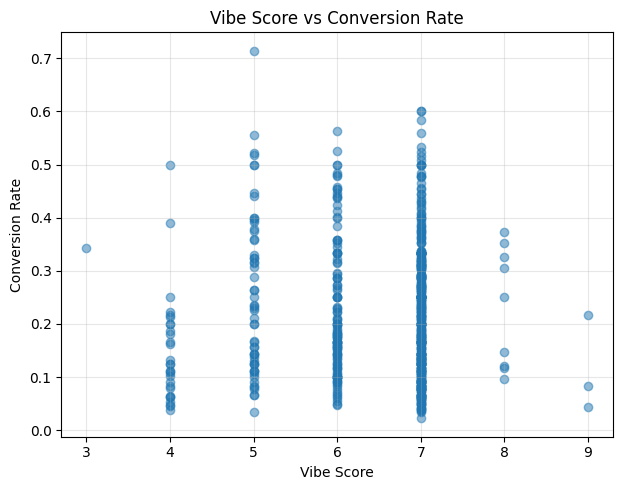

Korelacija (Vibe vs Conversion): 0.0041


In [ ]:
# Scatter plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(df_engagement['vibe_score'], df_engagement['conversion_rate'], alpha=0.5)
plt.xlabel('Vibe Score')
plt.ylabel('Conversion Rate')
plt.title('Vibe Score vs Conversion Rate')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr_vibe_conv = df_engagement['vibe_score'].corr(df_engagement['conversion_rate'])

print(f"Korelacija (Vibe vs Conversion): {corr_vibe_conv:.4f}")


# HIPOTEZA 3: Green Flags → Više Applies

Korelacija (Green Flags vs Conversion): -0.0668


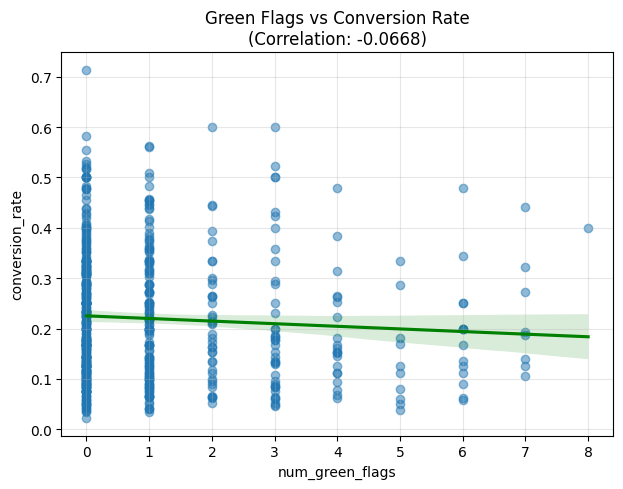

In [ ]:

corr_green_conv = df_engagement['num_green_flags'].corr(df_engagement['conversion_rate'])

print(f"Korelacija (Green Flags vs Conversion): {corr_green_conv:.4f}")
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 2)
sns.regplot(x='num_green_flags', y='conversion_rate', data=df_engagement,
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title(f'Green Flags vs Conversion Rate\n(Correlation: {corr_green_conv:.4f})')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# HIPOTEZA 4: Net Flags (Green - Red) vs CONVERSION

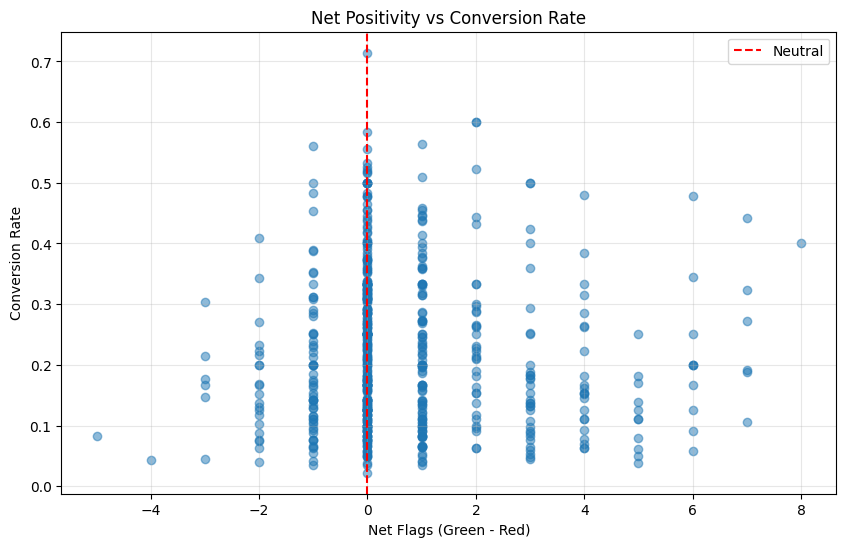


Korelacija (Net Flags vs Conversion): -0.0218


In [ ]:
df_engagement['net_flags'] = df_engagement['num_green_flags'] - df_engagement['num_red_flags']

plt.figure(figsize=(10, 6))
plt.scatter(df_engagement['net_flags'], df_engagement['conversion_rate'], alpha=0.5)
plt.xlabel('Net Flags (Green - Red)')
plt.ylabel('Conversion Rate')
plt.title('Net Positivity vs Conversion Rate')
plt.axvline(0, color='red', linestyle='--', label='Neutral')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

corr_net = df_engagement['net_flags'].corr(df_engagement['conversion_rate'])
print(f"\nKorelacija (Net Flags vs Conversion): {corr_net:.4f}")


# SVE KORELACIJE

In [ ]:

# Tvoj DataFrame
summary = pd.DataFrame({
    'Faktor': ['Tech Stack Diversity','Total techs', 'Red Flags', 'Green Flags', 'Net Flags', 'Vibe Score'],
    'vs Salary': [f'{new_corr:.4f}',f'{corr_volume:.4f}', '/', '/', '/', '/'],
    'vs Conversion Rate': ['/','/', f'{corr_red:.4f}', f'{corr_green_conv:.4f}', f'{corr_net:.4f}', f'{corr_vibe_conv:.4f}']})


print(tabulate(summary, headers='keys', tablefmt='fancy_grid', showindex=False))


╒══════════════════════╤═════════════╤══════════════════════╕
│ Faktor               │ vs Salary   │ vs Conversion Rate   │
╞══════════════════════╪═════════════╪══════════════════════╡
│ Tech Stack Diversity │ -0.0873     │ /                    │
├──────────────────────┼─────────────┼──────────────────────┤
│ Total techs          │ 0.0282      │ /                    │
├──────────────────────┼─────────────┼──────────────────────┤
│ Red Flags            │ /           │ -0.0949              │
├──────────────────────┼─────────────┼──────────────────────┤
│ Green Flags          │ /           │ -0.0668              │
├──────────────────────┼─────────────┼──────────────────────┤
│ Net Flags            │ /           │ -0.0218              │
├──────────────────────┼─────────────┼──────────────────────┤
│ Vibe Score           │ /           │ 0.0041               │
╘══════════════════════╧═════════════╧══════════════════════╛


---

##  **SUMA SUMARUM**

### **1. Tehnološki Ekosistem IT Tržišta**

**7 jasnih tehnoloških klastera**

**Python i AWS** su centralne tehnologije - pojavljuju se u svim oblastima

**Modularity 0.28** - validna podela, ali sa preklapanjima (full-stack pozicije)

---

### **2. Uticaj Širine Znanja na Platu**

**Hipoteza:** Šira raznolikost tehnoloških oblasti → Viša plata

**Rezultati:**
- **SVE pozicije:** r = 0.13 (slaba pozitivna korelacija)
- **Samo tehničke pozicije:** r = -0.08 (zanemarljivo)

**Interpretacija:**  
Rast korelacije potiče iz razlike između **netehničkih pozicija** (0 klastera, niža plata) i **tehničkih pozicija** (1+ klastera, viša plata). **Unutar tehničkih pozicija, širina znanja ne donosi značajno višu platu.**

**Zaključak:**  
Tržište **NE nagrađuje** generaliste značajno. Specijalizacija i seniority su važniji faktori od breadth-a znanja.

---

### **3. Uticaj Tona Oglasa na Angažovanje Kandidata**

**Hipoteza:** Red flags smanjuju, green flags povećavaju conversion rate

**Rezultati:**
| Faktor | Korelacija | Interpretacija |
|--------|-----------|----------------|
| Red Flags → Conversion | -0.09 | Zanemarljiva negativna |
| Green Flags → Conversion | -0.07 | Zanemarljivo (suprotno očekivanju!) |
| Vibe Score → Conversion | 0.00 | Nema uticaja |

**Zaključak:**  
Kandidati **ignorišu retoriku oglasa**. Odluke o aplikovanju se donose na osnovu **strukturnih faktora**: naziv pozicije, kompanija, plata, lokacija - **NE na osnovu tona** ili benefits marketing-a.

---

### **4. Ograničenja Istraživanja**


**LLM ekstrakcija:** Llama 3.3 70B je dobar, ali ne perfektan (tone detection subjektivan, nije efikasan ako se ne plati)  
**LinkedIn dataset:** Samo oglasi objavljeni na LinkedIn (nedostaju startup oglasi, direktne aplikacije, domaći oglasi)

---

### **5. Praktične Implikacije**

**Za kandidate:**
- Fokus na **specijalizaciju** unutar jedne oblasti umesto "svaštarenja"
- Ignorisati marketing speak - proceni kompaniju i poziciju objektivno
- Python i AWS su "passport" tehnologije - otvaraju vrata svuda

**Za poslodavce:**
- Ton oglasa **ne utiče** na broj aplikacija - fokus na jasnoću pozicije i benefite
- Red flags ne odvraćaju kandidate
- Transparentnost oko plate je ključna


---

## **Reference**

- Dataset: [LinkedIn Job Postings 2023-2024 (Kaggle)](https://www.kaggle.com/)
- LLM: Llama 3.3 70B Versatile (Groq API)
- Mrežna analiza: NetworkX, Louvain Community Detection
- Korelaciona analiza: Pandas, SciPy, Seaborn

---

##**Kraj analize**